In [1]:
# # Log my print statements to a log file
# import sys
# import datetime

# class Logger:
#     """Logs both to stdout (terminal) and a log file."""
#     def __init__(self, filename="log.txt"):
#         self.terminal = sys.stdout  # Keep reference to original stdout
#         self.log = open(filename, "a", encoding="utf-8")  # Append mode

#     def write(self, message):
#         self.terminal.write(message)  # Print to terminal
#         self.log.write(message)  # Write to log file
#         self.log.flush()  # Force flush after each write

#     def flush(self):
#         """Ensure real-time logging."""
#         self.terminal.flush()
#         self.log.flush()

# # Redirect stdout to Logger (All print statements will now go to log.txt)
# sys.stdout = Logger("log.txt")

# # Log start time
# print(f"\n===== Workflow Started: {datetime.datetime.now()} =====\n")

In [2]:
# NOTE: directly using model_summary csv files of /data/modelzoo/data_storage by Jason: 
# data_storage_path = "../../../../data/modelzoo/data_storage"

# copied from this path, and use it locally in project directory

# Generate Model Summaries CSV Files

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import chi2_contingency
from scipy.stats import skew


In [4]:
# After getting JSON files for model data ready, we can run model_summaries.py to get attribute matrices for each origin.
# The generated model summary csv files will be defaultly saved in the data_storage/results folder.
# takes a while to run the following commands

# currently, didn't re-run these commands and use the existing csv files here
# if you want to re-run these commands, please uncomment the following lines

# !python model_summaries.py give_summaries_timm
# !python model_summaries.py give_summaries_pytorch
# !python model_summaries.py give_summaries_tfhub
# !python model_summaries.py give_summaries_keras

# Analysis on Previous Model Collection's Model Metadata

## Read in model attribute matrix and metadata files

In [5]:
folder_save_plot = "plots"

# Read in the model_summaries csv files
# Use new csv files if the previous JSON files are updated
# right now it uses existing csv files

# combine data_storage_path with file relative paths (/modelData/models_summary_*.csv)
models_summaries_file_paths = [
    "data/models_summaries/models_summary_keras.csv",
    "data/models_summaries/models_summary_pytorch.csv",
    "data/models_summaries/models_summary_tfhub.csv",
    "data/models_summaries/models_summary_timm_new.csv"
]
#     "../../../../data/modelzoo/data_storage/modelData/models_summary_keras.csv",
#     "../../../../data/modelzoo/data_storage/modelData/models_summary_pytorch.csv",
#     "../../../../data/modelzoo/data_storage/modelData/models_summary_tfhub.csv",
#     "../../../../data/modelzoo/data_storage/modelData/models_summary_timm_new.csv"

# print(models_summaries_file_paths[0])
# print(os.path.exists(models_summaries_file_paths[0]))

In [6]:
import json
# Read in the JSON files in data/models_metadata to see how many models included in total and in each source
models_metadata_file_paths = [
    "data/models_metadata/hubModels_keras.json",
    "data/models_metadata/hubModels_pytorch.json",
    "data/models_metadata/hubModels_timm.json",
    "data/models_metadata/hubModels_tfhub.json" # named hubModels.json originally because this is the source Jason started with, but now it is the tfhub source
]

In [7]:
# read in the metadata files
total_metadata_models = 0
for i, file_path in enumerate(models_metadata_file_paths):
    with open(file_path, 'r') as f:
        metadata = json.load(f)
        print(f"--Number of models in {file_path}: {len(metadata)}--")
        # print the first item in the json file dict
       
        first_key = next(iter(metadata))  # Get the first key of the dictionary
        # print(f"First key: {first_key}")
        # print(f"First item: {metadata[first_key]}")  # Print the first item
        # print()
        print(f"Keys of the first item: {metadata[first_key].keys()}")
        print()

        total_metadata_models += len(metadata)
print(f"Total number of models with metadata in all sources: {total_metadata_models}")

# we would refer to attribute matrix mainly

--Number of models in data/models_metadata/hubModels_keras.json: 71--
Keys of the first item: dict_keys(['function', 'layerIdx', 'origin', 'type', 'parameters', 'trainingSet', 'num_params', 'num_layers'])

--Number of models in data/models_metadata/hubModels_pytorch.json: 10--
Keys of the first item: dict_keys(['function', 'trans_params', 'outputLayer', 'generative', 'origin', 'type', 'parameters', 'trainingSet', 'shape', 'task', 'num_params', 'num_layers'])

--Number of models in data/models_metadata/hubModels_timm.json: 611--
Keys of the first item: dict_keys(['url', 'num_classes', 'input_size', 'pool_size', 'crop_pct', 'interpolation', 'mean', 'std', 'first_conv', 'classifier', 'has_aux', 'label_offset', 'architecture', 'num_params', 'num_layers'])

--Number of models in data/models_metadata/hubModels_tfhub.json: 91--
Keys of the first item: dict_keys(['url', 'outputIdx', 'numFeatures', 'type', 'trainingSet', 'num_params', 'num_layers', 'task', 'origin'])

Total number of models wit

## Concatenate all the model summaries CSV files into one

### Sort columns, Add Origin, Remove models if redundent

In [8]:
models_summaries_all = []
# Concatenate all the dataframes, ensuring columns match

# Add "Origin" column based on file name
for file in models_summaries_file_paths:
    df = pd.read_csv(file)
    if "Origin" not in df.columns:
        if "keras" in file:
            df["Origin"] = "keras"
        elif "pytorch" in file:
            df["Origin"] = "pytorch"
        elif "tfhub" in file:
            df["Origin"] = "tfhub"
        elif "timm" in file:
            df["Origin"] = "timm"
    models_summaries_all.append(df)


# Find the union of all columns
all_columns = set()
for df in models_summaries_all:
    all_columns.update(df.columns)

# Reindex dataframes to have the same columns
models_summaries_all = [df.reindex(columns=all_columns) for df in models_summaries_all]

# Concatenate the dataframes
models_summaries_all = pd.concat(models_summaries_all, ignore_index=True)

### Check if the amount of models align with existing sims file

In [9]:
# check if the total amount of models == 774 showed in the sims files

# read in a sims data
sims_file_path = "data/sims/yufos.csv"
sims_data = pd.read_csv(sims_file_path)

# check if the models in sims are in the models_summaries_all
sims_data_models = sims_data.columns[1:]
models_summaries_all_models = models_summaries_all["Model"].values
print("Number of models in sims data:", len(sims_data_models))
print("Number of models in models_summaries_all:", len(models_summaries_all_models))
print("Number of models in metadata:", total_metadata_models)
print()
print("Number of models in sims but not in models_summaries_all:", len(set(sims_data_models) - set(models_summaries_all_models)))
print("Number of models in models_summaries_all but not in sims:", len(set(models_summaries_all_models) - set(sims_data_models)))
print()




# print the models in models_summaries_all but not in sims
print("Models in models_summaries_all but not in sims:")
print("Total:", len(set(models_summaries_all_models) - set(sims_data_models)))
for model in set(models_summaries_all_models) - set(sims_data_models):
    # # print these models in a list
    # print(model)
    # save the model names to a text file
    with open("data/models_in_models_summaries_all_but_not_in_sims.txt", "a") as f:
        f.write(model + "\n")
print()

# print the models in sims but not in models_summaries_all
print("Models in sims but not in models_summaries_all:")
print("Total:", len(set(sims_data_models) - set(models_summaries_all_models)))
for model in set(sims_data_models) - set(models_summaries_all_models):
    # print these models in a list
    # print(model)
    # save the model names to a text file
    with open("data/models_in_sims_but_not_in_models_summaries_all.txt", "a") as f:
        f.write(model + "\n")
print()

    

Number of models in sims data: 774
Number of models in models_summaries_all: 928
Number of models in metadata: 783

Number of models in sims but not in models_summaries_all: 100
Number of models in models_summaries_all but not in sims: 239

Models in models_summaries_all but not in sims:
Total: 239

Models in sims but not in models_summaries_all:
Total: 100



### Check duplicated models

In [10]:
# Check for duplicates who has the same "Model" string
duplicated_models = models_summaries_all["Model"].duplicated()
count = 0
if duplicated_models.any():
    print("Duplicated models:", models_summaries_all[duplicated_models]["Model"].values)
    for model in models_summaries_all[duplicated_models]["Model"].values:
        # see if the duplicated model has different origin
        if len(set(models_summaries_all[models_summaries_all["Model"] == model]["Origin"])) > 1:
            # print("Duplicated model from different origin:", model)
            # drop the row for the duplicates if the origin is keras (keras has less information than timm)
            models_summaries_all = models_summaries_all.drop(models_summaries_all[(models_summaries_all["Model"] == model) & (models_summaries_all["Origin"] == "keras")].index)
            # print("Dropped the row for the duplicated model from keras and keep timm:", model)
            count += 1
    print("Dropped", count, "duplicated models from keras")


# Only include models if they are both in the model summaries and the sims data
sims_data_models = sims_data.columns
print(len(sims_data_models)-1, "models in sims data")

models_summaries_all = models_summaries_all.loc[models_summaries_all["Model"].isin(sims_data_models)]
print("Dropped models that are not in sims data", len(models_summaries_all), "models left")


print("Number of models:", len(models_summaries_all))
print("Number of unique models:", len(models_summaries_all["Model"].unique()))
print("Verified, Models are all unique" if len(models_summaries_all) == len(models_summaries_all["Model"].unique()) else "Still have duplicates: Models are not all unique")

Duplicated models: ['convnext_base' 'convnext_large' 'convnext_small' 'convnext_tiny'
 'densenet121' 'densenet169' 'densenet201' 'inception_resnet_v2'
 'inception_v3' 'resnet50' 'resnet101' 'resnet152' 'vgg16' 'vgg19'
 'xception']
Dropped 15 duplicated models from keras
774 models in sims data
Dropped models that are not in sims data 674 models left
Number of models: 674
Number of unique models: 674
Verified, Models are all unique


### Add family data and Binary attributes from previous framework

In [11]:
# Load family and left join
family_data_path = "data/models_summaries/family_data.csv"
family_data = pd.read_csv(family_data_path)

# Add binary attributes
attributes_binary = [
    "Convolutional Layers",
    "Residual Blocks",
    "Dense Layers",
    "Bottlenecks",
    "Recurrent Layers",
    "Skip Connections",
    "Attention Layers",
    "ReLU", # for categorical attributes (most common activation function)
    "GeLU", # for categorical attributes (most common activation function)
]

family_data = family_data.rename(columns={col: "Has " + col for col in attributes_binary})


# Merge family data into the models summaries
models_summaries_all = pd.merge(models_summaries_all, family_data, on="Family", how="left")

# make has ReLU and has GeLU as a combined categorical attribute (Most common activation function)
models_summaries_all["Has ReLU"] = models_summaries_all["Has ReLU"].fillna(0)
models_summaries_all["Has GeLU"] = models_summaries_all["Has GeLU"].fillna(0)
for i, row in models_summaries_all.iterrows():
    if row["Has ReLU"] == 1 and row["Has GeLU"] == 0:
        models_summaries_all.at[i, "Most Common Activation Function"] = "ReLU"
    elif row["Has ReLU"] == 0 and row["Has GeLU"] == 1:
        models_summaries_all.at[i, "Most Common Activation Function"] = "GeLU"
    elif row["Has ReLU"] == 1 and row["Has GeLU"] == 1:
        # models_summaries_all.at[i, "Most Common Activation Function"] = "ReLU" # if both are 1, then set to ReLU
        models_summaries_all.at[i, "Most Common Activation Function"] = "ReLU, GeLU"
    else:
        models_summaries_all.at[i, "Most Common Activation Function"] = "NA" # if both are 0, then set to NA


<!-- ### Scale down and rename attributes like previous framework -->

In [12]:
# # scale down parameters to be in the millions
# models_summaries_all["Parameters"] = models_summaries_all["Parameters"] / 1_000_000

# # Scale down layers by 10
# models_summaries_all["Layers"] = models_summaries_all["Layers"] / 10



In [13]:
# print the column names
print(models_summaries_all.columns)

Index(['Training Dataset', 'Bottlenecks', 'Dense Layers',
       'Last Layer Parameters', 'Highest Internal Layer Parameters',
       'Lowest Internal Layer Parameters', 'Output Features', 'Conv Layers',
       'Origin', 'RF25 Layer Number', 'Residual Blocks',
       'First Layer Parameters', 'Architecture', 'RF25 Layer Name',
       'Pooling Layers', 'Max RF', 'Parameters', 'Layers', 'Model',
       'Recurrent Layers', 'Attention Layers', 'Crop Percentage', 'Family',
       'MAX RF', 'Normalization Layers', 'Has Convolutional Layers',
       'Has Residual Blocks', 'Has Dense Layers', 'Has Bottlenecks',
       'Has Recurrent Layers', 'Has Skip Connections', 'Has Attention Layers',
       'Tokenized', 'Transformer', 'Has ReLU', 'Has GeLU', 'Other',
       'Year Made', 'Learning Type', 'Primary Application',
       'Key Distinguishing Feature', 'Pooling',
       'Most Common Activation Function'],
      dtype='object')


In [14]:
# rename the columns to be consistent with manuscript

# rename the following continuous factors
factors_continuous = [
    "Attention Layers",
    "Convolutional Layers",
    "Dense Layers",
    "Highest Internal Layer Parameters",
    "Layers",
    "Lowest Internal Layer Parameters",
    "Normalization Layers",
    "Output Features",
    "First Layer Parameters",
    "Last Layer Parameters",
    "Pooling Layers",
    "Parameters"
]
models_summaries_all = models_summaries_all.rename(columns={"Conv Layers": "Convolutional Layers"})

# rename the columns to be consistent with manuscript (add "Number of " in front of the column name)
for con_fac in factors_continuous:
    models_summaries_all = models_summaries_all.rename(columns={con_fac: "Number of " + con_fac})
    # update the column name in the list
    factors_continuous[factors_continuous.index(con_fac)] = "Number of " + con_fac


# rename the following categorical factors
factors_categorical = [
    "Architecture Family",
    "Most Common Pooling Type",
    "Primary Application", # already
    "Training Dataset", # already
    "Training Type",
    "Most Common Activation Function" # already
]
models_summaries_all = models_summaries_all.rename(columns={"Family": "Architecture Family"})
models_summaries_all = models_summaries_all.rename(columns={"Pooling": "Most Common Pooling Type"})
models_summaries_all = models_summaries_all.rename(columns={"Learning Type": "Training Type"})

# binary factors already named consistently, here we just define the list
factors_binary = [
    "Has Attention Layers",
    "Has Bottlenecks",
    "Has Convolutional Layers",
    "Has Dense Layers",
    "Has Residual Blocks",
    "Has Skip Connections",
    "Tokenized"
]

print(models_summaries_all.columns)


Index(['Training Dataset', 'Bottlenecks', 'Number of Dense Layers',
       'Number of Last Layer Parameters',
       'Number of Highest Internal Layer Parameters',
       'Number of Lowest Internal Layer Parameters',
       'Number of Output Features', 'Number of Convolutional Layers', 'Origin',
       'RF25 Layer Number', 'Residual Blocks',
       'Number of First Layer Parameters', 'Architecture', 'RF25 Layer Name',
       'Number of Pooling Layers', 'Max RF', 'Number of Parameters',
       'Number of Layers', 'Model', 'Recurrent Layers',
       'Number of Attention Layers', 'Crop Percentage', 'Architecture Family',
       'MAX RF', 'Number of Normalization Layers', 'Has Convolutional Layers',
       'Has Residual Blocks', 'Has Dense Layers', 'Has Bottlenecks',
       'Has Recurrent Layers', 'Has Skip Connections', 'Has Attention Layers',
       'Tokenized', 'Transformer', 'Has ReLU', 'Has GeLU', 'Other',
       'Year Made', 'Training Type', 'Primary Application',
       'Key Disting

### Save the concatenated file

In [15]:
# Save the concatenated dataframe
models_summaries_all.to_csv(f"data/models_summary_all_raw.csv", index=False)

# Pre-Analysis and Cleanning on the concatenated file of all models' attributes

In [16]:
# Read the combined CSV file
models_summaries_all = pd.read_csv("data/models_summary_all_raw.csv")

## Get attributes' types

In [17]:
# print all column names
print(f"All {len(models_summaries_all.columns)} attributes: {models_summaries_all.columns}")
print() # consistent with Jason's manuscript code

# Find the categorical and numerical columns
attribute_categorical_columns = []
attribute_continuous_columns = []
attribute_binary_columns = []

# Find the columns with missing data
attribute_missing_data_columns = []

# Find the columns with missing data, categorical columns, binary columns, and continuous columns
for column in models_summaries_all.columns:
    # print(f"Checking column: {column}")

    # Check if have missing data
    if models_summaries_all[column].isnull().any():
        attribute_missing_data_columns.append(column)
        # print(f"    {column} has missing data")
        # print(f"    Number of missing data: {models_summaries_all[column].isnull().sum()}")
        # print(f"    Percentage of missing data: {models_summaries_all[column].isnull().sum() / models_summaries_all.shape[0] * 100}%")
        # print()

    # Check if the column is categorical
    if models_summaries_all[column].dtype in ["object"]:
        attribute_categorical_columns.append(column)
        continue
        # print(f"    {column} is categorical")
        # print(f"    Number of unique values: {models_summaries_all[column].nunique()}")
        # print()

    # Check if the column is binary (only have 0 and 1)
    # TODO: Jason's manuscript code has categorical columns list categoricalCols
    elif models_summaries_all[column].dtype in ["int64", "float64"] and models_summaries_all[column].nunique() == 2:
        # further check if the values are in [0, 1]
        if set(models_summaries_all[column].dropna().unique()).issubset({0.0, 1.0}):
            attribute_binary_columns.append(column)
            continue
        # print(f"    {column} is binary")
        # print()

    # Check if the column is numerical and not binary (meaning continuous data)
    elif models_summaries_all[column].dtype in ["int64", "float64"] and models_summaries_all[column].nunique() > 2 and not set(models_summaries_all[column].dropna().unique()).issubset({0.0, 1.0}):
        attribute_continuous_columns.append(column)
        continue


    

print("Finished checking columns")
print(f"Categorical columns: {len(attribute_categorical_columns)}")
print(f"Categorical columns include: {attribute_categorical_columns}")
print()
print(f"Binary columns: {len(attribute_binary_columns)}")
print(f"Binary columns include: {attribute_binary_columns}")
print()
print(f"Continuous columns: {len(attribute_continuous_columns)}")
print(f"Continuous columns include: {attribute_continuous_columns}")
print()
print(f"In total: {len(attribute_categorical_columns) + len(attribute_binary_columns) + len(attribute_continuous_columns)}")
print(f"where Missing data columns: {len(attribute_missing_data_columns)}")
print()
      

All 43 attributes: Index(['Training Dataset', 'Bottlenecks', 'Number of Dense Layers',
       'Number of Last Layer Parameters',
       'Number of Highest Internal Layer Parameters',
       'Number of Lowest Internal Layer Parameters',
       'Number of Output Features', 'Number of Convolutional Layers', 'Origin',
       'RF25 Layer Number', 'Residual Blocks',
       'Number of First Layer Parameters', 'Architecture', 'RF25 Layer Name',
       'Number of Pooling Layers', 'Max RF', 'Number of Parameters',
       'Number of Layers', 'Model', 'Recurrent Layers',
       'Number of Attention Layers', 'Crop Percentage', 'Architecture Family',
       'MAX RF', 'Number of Normalization Layers', 'Has Convolutional Layers',
       'Has Residual Blocks', 'Has Dense Layers', 'Has Bottlenecks',
       'Has Recurrent Layers', 'Has Skip Connections', 'Has Attention Layers',
       'Tokenized', 'Transformer', 'Has ReLU', 'Has GeLU', 'Other',
       'Year Made', 'Training Type', 'Primary Application',


## Overview of the attributes' types and empty data

In [18]:
# show a summary on the attributes' types
attribute_table = pd.DataFrame({
    "Attribute": models_summaries_all.columns,
    "Attribute Type": ["Categorical" if col in attribute_categorical_columns else "Binary" if col in attribute_binary_columns else "Continuous" for col in models_summaries_all.columns],
    "Empty data": [models_summaries_all[col].isnull().sum() for col in models_summaries_all.columns],
    "Unique values": [models_summaries_all[col].nunique() for col in models_summaries_all.columns]
})

# Add a column "Factor Type" to record whether they were included in previous analysis
for i, row in attribute_table.iterrows():
    if row["Attribute"] in factors_continuous:
        attribute_table.at[i, "Factor Type"] = "Continuous"
    elif row["Attribute"] in factors_categorical:
        attribute_table.at[i, "Factor Type"] = "Categorical"
    elif row["Attribute"] in factors_binary:
        attribute_table.at[i, "Factor Type"] = "Binary"
    else:
        attribute_table.at[i, "Factor Type"] = "NA"


# order by the attribute
attribute_table = attribute_table.sort_values(by="Attribute")
# order by the type
attribute_table = attribute_table.sort_values(by="Attribute Type")
# order by missing data percentage
attribute_table = attribute_table.sort_values(by="Empty data", ascending=True)

# show the table (without column index)
print(attribute_table.to_string(index=False))

# save the table
attribute_table.to_csv("data/attribute_table_withNA.csv", index=False)

                                  Attribute Attribute Type  Empty data  Unique values Factor Type
                                   Has GeLU         Binary           0              2          NA
                                   Has ReLU         Binary           0              2          NA
                                     Origin    Categorical           0              4          NA
                  Number of Output Features     Continuous           0              9  Continuous
                       Number of Parameters     Continuous           0            564  Continuous
                                      Model    Categorical           0            674          NA
                        Architecture Family    Categorical           0             81 Categorical
                           Training Dataset    Categorical           0              6 Categorical
                           Number of Layers     Continuous           0            283  Continuous
                    

NOTE: The attribute_table_withNA.csv was analyzed and formatted as table by Excel based on factors included by Jason, named Table 1 in manuscript.  

## Clean unnecessary attributes and Handle empty data 

In [19]:
models_summaries_all_clean = models_summaries_all

# First, drop unuseful columns
for column in models_summaries_all_clean.columns:
    if models_summaries_all_clean[column].isnull().sum() > 600:
        print(f"Dropping column {column} with {models_summaries_all_clean[column].isnull().sum()} missing values")
        models_summaries_all_clean = models_summaries_all_clean.drop(columns=[column])
        if column in attribute_categorical_columns:
            attribute_categorical_columns.remove(column)
        if column in attribute_binary_columns:
            attribute_binary_columns.remove(column)
        if column in attribute_continuous_columns:
            attribute_continuous_columns.remove(column)
        continue
    if column in ["Has GeLU", "Has ReLU", "Architecture", "Other"]:
        print(f"Dropping column {column} because it is not useful")
        models_summaries_all_clean = models_summaries_all_clean.drop(columns=[column])
        if column in attribute_categorical_columns:
            attribute_categorical_columns.remove(column)
        if column in attribute_binary_columns:
            attribute_binary_columns.remove(column)
        if column in attribute_continuous_columns:
            attribute_continuous_columns.remove(column)
        continue
    if models_summaries_all_clean[column].nunique() == 1:
        # if the column has only one unique value, drop it
        print(f"Dropping column {column} because it has only one unique value")
        models_summaries_all_clean = models_summaries_all_clean.drop(columns=[column])
        if column in attribute_categorical_columns:
            attribute_categorical_columns.remove(column)
        if column in attribute_binary_columns:
            attribute_binary_columns.remove(column)
        if column in attribute_continuous_columns:
            attribute_continuous_columns.remove(column)
        continue

# Second, fill in binary attributes based on available information and logic
for col in attribute_binary_columns:
    col_continuous = col.replace("Has ", "Number of ")
    print(f"Checking column: {col}")
    # if the column is continuous and has a corresponding binary column
    if col_continuous in models_summaries_all_clean.columns:
        # if the column is binary and the continuous column > 0, then set the binary column to 1
        models_summaries_all_clean.loc[models_summaries_all_clean[col_continuous] > 0, col] = 1
        # if the column is binary and the continuous column == 0, then set the binary column to 0
        models_summaries_all_clean.loc[models_summaries_all_clean[col_continuous] == 0, col] = 0
    
    if col == "Transformer":
        # if attention layers > 0, then set the column to 1
        models_summaries_all_clean.loc[models_summaries_all_clean["Number of Attention Layers"] > 0, col] = 1
    if col == "Tokenized":
        # if has attention layers but don't have convolutional layer, then set the column to 1
        models_summaries_all_clean.loc[(models_summaries_all_clean["Has Attention Layers"] == 1) & (models_summaries_all_clean["Has Convolutional Layers"] == 0), col] = 1

# Fill in the missing values with NA for categorical columns
for column in attribute_categorical_columns:
    # fill in "NA" for categorical columns
    models_summaries_all_clean[column] = models_summaries_all_clean[column].fillna("NA")
    models_summaries_all_clean[column] = models_summaries_all_clean[column].replace("", "NA")
    if models_summaries_all_clean[column].isnull().any():
        print(f"Column {column} still has missing data after filling with 'NA'")
# Fill in the missing values with 0 for binary columns
for column in attribute_binary_columns:
    # fill in 0 for binary columns
    models_summaries_all_clean[column] = models_summaries_all_clean[column].fillna(0)
    models_summaries_all_clean[column] = models_summaries_all_clean[column].replace("", 0)
    if models_summaries_all_clean[column].isnull().any():
        print(f"Column {column} still has missing data after filling with 'NA'")

# for all continuous attributes, add "Number of " in front of the column name (if not already)
for attribute in attribute_continuous_columns:
    if not attribute.startswith("Number of "):
        if attribute in ["Year Made", "Crop Percentage"]:
            continue
        else:
            models_summaries_all_clean = models_summaries_all_clean.rename(columns={attribute: "Number of " + attribute})
            # update the column name in the list
            attribute_continuous_columns[attribute_continuous_columns.index(attribute)] = "Number of " + attribute

print("Finished checking columns")
print(f"Categorical columns: {len(attribute_categorical_columns)}")
print(f"Categorical columns include: {attribute_categorical_columns}")
print()
print(f"Binary columns: {len(attribute_binary_columns)}")
print(f"Binary columns include: {attribute_binary_columns}")
print()
print(f"Continuous columns: {len(attribute_continuous_columns)}")
print(f"Continuous columns include: {attribute_continuous_columns}")
print()

attribute_table = pd.DataFrame({
    "Attribute": models_summaries_all_clean.columns,
    "Attribute Type": ["Categorical" if col in attribute_categorical_columns else "Binary" if col in attribute_binary_columns else "Continuous" for col in models_summaries_all_clean.columns],
    "Empty data": [models_summaries_all_clean[col].isnull().sum() for col in models_summaries_all_clean.columns],
    "Unique values": [models_summaries_all_clean[col].nunique() for col in models_summaries_all_clean.columns]
})

# Add a column "Factor Type" to record whether they were included in previous analysis
for i, row in attribute_table.iterrows():
    if row["Attribute"] in factors_continuous:
        attribute_table.at[i, "Factor Type"] = "Continuous"
    elif row["Attribute"] in factors_categorical:
        attribute_table.at[i, "Factor Type"] = "Categorical"
    elif row["Attribute"] in factors_binary:
        attribute_table.at[i, "Factor Type"] = "Binary"
    else:
        attribute_table.at[i, "Factor Type"] = "NA"


# order by the attribute
attribute_table = attribute_table.sort_values(by="Attribute")
# order by the type
attribute_table = attribute_table.sort_values(by="Attribute Type")
# order by missing data percentage
attribute_table = attribute_table.sort_values(by="Empty data", ascending=True)

# show the table (without column index)
print(attribute_table.to_string(index=False))

# save the table
attribute_table.to_csv("data/attribute_table_filled.csv", index=False)

Dropping column RF25 Layer Number with 673 missing values
Dropping column Architecture because it is not useful
Dropping column RF25 Layer Name with 673 missing values
Dropping column Max RF with 674 missing values
Dropping column MAX RF with 673 missing values
Dropping column Has Recurrent Layers because it has only one unique value
Dropping column Has ReLU because it is not useful
Dropping column Has GeLU because it is not useful
Dropping column Other because it is not useful
Checking column: Has Convolutional Layers
Checking column: Has Residual Blocks
Checking column: Has Dense Layers
Checking column: Has Bottlenecks
Checking column: Has Skip Connections
Checking column: Has Attention Layers
Checking column: Tokenized
Checking column: Transformer
Finished checking columns
Categorical columns: 9
Categorical columns include: ['Training Dataset', 'Origin', 'Model', 'Architecture Family', 'Training Type', 'Primary Application', 'Key Distinguishing Feature', 'Most Common Pooling Type', 

## Save the clean data

In [20]:
# Save the concatenated dataframe
models_summaries_all_clean.to_csv(f"data/models_summary_all_clean.csv", index=False)

<hr>

# 1. Distribution of All Attributes


In [21]:
# for each column of the attribute matrix, plot the distribution of models by that column

folder_save = "plots"

for column in models_summaries_all_clean.columns:
    # # if half of the rows are missing, skip this column
    # if models_summaries_all_clean[column].isnull().sum() > len(models_summaries_all_clean) / 2:
    #     print(f"Skipping {column} because more than half of the rows are missing.")
    #     continue
    
    if column == "id":
        print(f"Skipping {column} because it's an index.")
        continue

    print(f"Plotting {column}...")

    # categorical columns
    if column in attribute_categorical_columns:
        if column in ["Architecture"] :
            print(f"Skipping {column} because not useful.")
            continue
        num_unique = int(models_summaries_all_clean[column].nunique())
        plt.figure(figsize=(max(10, int(num_unique * 0.5)), 12))
        
        column_counts = models_summaries_all_clean[column].value_counts()
        # print(f"Number of unique models: {num_unique}")
        # print(f"Total rows: {len(models_summaries_all_clean)}")
        
        if num_unique == len(models_summaries_all_clean):
            print(f"Alert: {column} has unique values for each row. Skipping for plotting.")
            continue
        elif num_unique > 100:
            num_unique = int(30)
            # when num_unique > 30, combine the least frequent values into "Others"
            column_counts = column_counts[:30]
            column_counts["Others"] = models_summaries_all_clean[column].value_counts()[30:].sum()
            # print(f"Number of unique models after combining: {num_unique}")
            # print(f"Total rows after combining: {column_counts.sum()}")
        # if num_unique > 30 and column == "Architecture Family":
        #     # make a horizontal bar plot
        #     plt.figure(figsize=(12, max(10, int(num_unique * 0.5))))
        #     column_counts.plot(kind='barh', edgecolor='black')
        #     # plt.gca().invert_yaxis()
        #     # plt.gca().set_aspect('auto')
        # else:
        column_counts.plot(kind='bar', edgecolor='black')
        for i in range(int(num_unique)):
            plt.text(i, column_counts.iloc[i], column_counts.iloc[i], ha='center', va='bottom')
        plt.xlabel(column)
        plt.ylabel('Number of models')
        plt.title(f'Distribution of models by {column}')
        if num_unique > 30:
            plt.xticks(rotation=60, ha='right')
        else:
            plt.xticks(rotation=10, ha='right')
        # add numbers on top of each bar
        for i in range(int(num_unique)):
            plt.text(i, column_counts.iloc[i], f"{column_counts.iloc[i]}", ha='center', va='bottom')
        plt.grid(axis='y', alpha=0.4)
        plt.gca().set_xticks(range(num_unique))
        plt.savefig(f'{folder_save}/dist_categorical_{column}_model_distribution.png')
        plt.close()

    # Continuous columns
    elif column in attribute_continuous_columns:
        plt.figure(figsize=(6, 6))
        models_summaries_all_clean[column].plot(kind='hist', bins=30, edgecolor='black')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        # add mean, median, and std to the title
        mean = models_summaries_all_clean[column].mean()
        median = models_summaries_all_clean[column].median()
        std = models_summaries_all_clean[column].std()
        plt.title(f'Distribution of models by {column}\nMean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.4)
        plt.axvline(models_summaries_all_clean[column].mean(), linestyle='dashed', color='red', alpha=0.5, linewidth=1)
        models_summaries_all_clean[column].plot(kind='kde', secondary_y=True, color="red", linewidth=1, alpha=0.5, label='KDE Density')
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        plt.savefig(f'{folder_save}/dist_continuous_{column}_model_distribution.png')
        plt.close()

    # Binary columns
    elif column in attribute_binary_columns:
        plt.figure(figsize=(6, 6))
        models_summaries_all_clean[column].value_counts().plot(kind='bar', edgecolor='black')
        plt.xlabel(column)
        plt.ylabel('Number of models')
        plt.title(f'Distribution of models by {column}')
        plt.xticks(rotation=0, ha='center')
        plt.grid(axis='y', alpha=0.4)
        # add percentage on top of each bar
        for i in range(len(models_summaries_all_clean[column].value_counts())):
            plt.text(i, models_summaries_all_clean[column].value_counts().iloc[i], f"{models_summaries_all_clean[column].value_counts().iloc[i] / len(models_summaries_all) * 100:.2f}%", ha='center', va='bottom')
        plt.savefig(f'{folder_save}/dist_binary_{column}_model_distribution.png')
        plt.close()

Plotting Training Dataset...


Plotting Number of Bottlenecks...
Plotting Number of Dense Layers...
Plotting Number of Last Layer Parameters...
Plotting Number of Highest Internal Layer Parameters...
Plotting Number of Lowest Internal Layer Parameters...
Plotting Number of Output Features...
Plotting Number of Convolutional Layers...
Plotting Origin...
Plotting Number of Residual Blocks...
Plotting Number of First Layer Parameters...
Plotting Number of Pooling Layers...
Plotting Number of Parameters...
Plotting Number of Layers...
Plotting Model...
Alert: Model has unique values for each row. Skipping for plotting.
Plotting Number of Recurrent Layers...
Plotting Number of Attention Layers...
Plotting Crop Percentage...
Plotting Architecture Family...
Plotting Number of Normalization Layers...
Plotting Has Convolutional Layers...
Plotting Has Residual Blocks...
Plotting Has Dense Layers...
Plotting Has Bottlenecks...
Plotting Has Skip Connections...
Plotting Has Attention Layers...
Plotting Tokenized...
Plotting Tran

<Figure size 33700x1200 with 0 Axes>

In [22]:
# for each column of the attribute matrix, save the distribution of models by that column in csv table

folder_save = "plots"

for column in models_summaries_all_clean.columns:
    if column == "id":
        print(f"Skipping {column} because it's an index.")
        continue

    print(f"Processing {column}...")

    # Categorical columns
    if column in attribute_categorical_columns:
        column_counts = models_summaries_all_clean[column].value_counts()
        column_counts.to_csv(f'{folder_save}/dist_categorical_{column}_model_distribution.csv', header=['Count'])

    # Continuous columns
    elif column in attribute_continuous_columns:
        # Save the distribution as a CSV file
        stats = models_summaries_all_clean[column].describe()
        stats.to_csv(f'{folder_save}/dist_continuous_{column}_model_distribution.csv', header=['Value'])

    # Binary columns
    elif column in attribute_binary_columns:
        column_counts = models_summaries_all_clean[column].value_counts()
        column_counts.to_csv(f'{folder_save}/dist_binary_{column}_model_distribution.csv', header=['Count'])


Processing Training Dataset...
Processing Number of Bottlenecks...
Processing Number of Dense Layers...
Processing Number of Last Layer Parameters...
Processing Number of Highest Internal Layer Parameters...
Processing Number of Lowest Internal Layer Parameters...
Processing Number of Output Features...
Processing Number of Convolutional Layers...
Processing Origin...
Processing Number of Residual Blocks...
Processing Number of First Layer Parameters...
Processing Number of Pooling Layers...
Processing Number of Parameters...
Processing Number of Layers...
Processing Model...
Processing Number of Recurrent Layers...
Processing Number of Attention Layers...
Processing Crop Percentage...
Processing Architecture Family...
Processing Number of Normalization Layers...
Processing Has Convolutional Layers...
Processing Has Residual Blocks...
Processing Has Dense Layers...
Processing Has Bottlenecks...
Processing Has Skip Connections...
Processing Has Attention Layers...
Processing Tokenized..

In [23]:
# save a integrated table with distribution info for manuscript, final table in manuscript is formatted in Excel pivot table

# Output storage
summary_continuous = []
summary_categorical = []
summary_binary = []

for col in models_summaries_all_clean.columns:
    if col == "id":
        continue

    # Determine attribute type (always one of the three)
    if col in attribute_continuous_columns:
        attr_type = "Continuous"
    elif col in attribute_binary_columns:
        attr_type = "Binary"
    elif col in attribute_categorical_columns:
        attr_type = "Categorical"
    else:
        continue  # skip if not in any known type

    # Determine factor type (may be NA)
    if col in factors_continuous:
        factor_type = "Continuous"
    elif col in factors_binary:
        factor_type = "Binary"
    elif col in factors_categorical:
        factor_type = "Categorical"
    else:
        factor_type = "NA"

    count_empty = models_summaries_all_clean[col].isna().sum()
    num_unique = models_summaries_all_clean[col].nunique()
    col_data = models_summaries_all_clean[col].dropna()
    

    # === Continuous attributes ===
    if attr_type == "Continuous":
        summary_continuous.append({
            "Attribute": col,
            "Factor Type": factor_type,
            "Min": round(col_data.min(), 2),
            "Max": round(col_data.max(), 2),
            "Mean": round(col_data.mean(), 2),
            "SD": round(col_data.std(), 2),
            "Skewness": round(skew(col_data), 2),
            "Count Empty": count_empty,
            "Unique Values": num_unique
        })

    # === Categorical attributes ===
    elif attr_type == "Categorical":
        value_counts = col_data.value_counts()
        mode = value_counts.idxmax() if not value_counts.empty else "NA"
        summary_categorical.append({
            "Attribute": col,
            "Factor Type": factor_type,
            "Mode": mode,
            "Mode Count": value_counts.max() if not value_counts.empty else "NA",
            "Max Category Count": value_counts.max() if not value_counts.empty else "NA",
            "Count Empty": count_empty,
            "Unique Values": num_unique
        })

    # === Binary attributes ===
    elif attr_type == "Binary":
        count_1 = (col_data == 1).sum()
        count_0 = (col_data == 0).sum()
        total = count_0 + count_1
        summary_binary.append({
            "Attribute": col,
            "Factor Type": factor_type,
            "Count 1": count_1,
            "Count 0": count_0,
            "Proportion 1": round(count_1 / total, 3) if total > 0 else "NA",
            "Proportion 0": round(count_0 / total, 3) if total > 0 else "NA",
            "Count Empty": count_empty,
            "Unique Values": num_unique
        })

# Convert to DataFrames
df_cont = pd.DataFrame(summary_continuous)
df_cat = pd.DataFrame(summary_categorical)
df_bin = pd.DataFrame(summary_binary)

# Sort and save
df_cont = df_cont.sort_values(by="Attribute")
df_cat = df_cat.sort_values(by="Attribute")
df_bin = df_bin.sort_values(by="Attribute")

df_cont.to_csv(f"{folder_save}/dist_summary_continuous_attributes.csv", index=False)
df_cat.to_csv(f"{folder_save}/dist_summary_categorical_attributes.csv", index=False)
df_bin.to_csv(f"{folder_save}/dist_summary_binary_attributes.csv", index=False)

## Check the family distribution of the models pre-trained with ImageNet-1K

In [24]:
# for the "Training Dataset == ImageNet-1K", we want to have a bar plot based on family

# filter the data
models_summaries_all_imagenet = models_summaries_all_clean[models_summaries_all["Training Dataset"] == "ImageNet-1K"]

# group by family
models_summaries_all_imagenet_family = models_summaries_all_imagenet.groupby("Architecture Family").size().reset_index(name="Count")

# sort by count
models_summaries_all_imagenet_family = models_summaries_all_imagenet_family.sort_values(by="Count", ascending=True)

# plot the bar plot
plt.figure(figsize=(10, 15))
plt.barh(models_summaries_all_imagenet_family["Architecture Family"], models_summaries_all_imagenet_family["Count"])
# mark the number of models
for i, v in enumerate(models_summaries_all_imagenet_family["Count"]):
    plt.text(v, i, str(v), color='black', va='center')
plt.title("Number of models in ImageNet-1K by Architecture Family")
plt.xlabel("Number of models")
plt.ylabel("Architecture Family")
plt.tight_layout()
plt.savefig("plots/dist_continuous_architecture_family_distribution_imagenet1k.png")
plt.close()


# 2. Analysis on Continuous Attributes

## Sort the continuous attributes by meanings

In [25]:
# sort the continuous attributes alphabetically
attribute_continuous_columns.sort()

# group the continuous attribute by type
# if ending with Layers, put together (first would be Number of Layers)
attribute_continuous_columns_sorted = []
# append the ones included in continuous factors first

attribute_continuous_columns_sorted.append("Number of Layers")
for attribute in factors_continuous:
    if attribute.endswith("Layers") and not attribute.startswith("Number of Layers"):
        attribute_continuous_columns_sorted.append(attribute)
        # print(attribute)

attribute_continuous_columns_sorted.append("Number of Parameters")
for attribute in factors_continuous:
    if attribute.endswith("Parameters") and not attribute.startswith("Number of Parameters"):
        attribute_continuous_columns_sorted.append(attribute)
        # print(attribute)
        
# append the rest
for attribute in factors_continuous:
    if attribute not in attribute_continuous_columns_sorted:
        attribute_continuous_columns_sorted.append(attribute)

# append the ones not included in continuous factors
for attribute in attribute_continuous_columns:
    if attribute not in attribute_continuous_columns_sorted:
        attribute_continuous_columns_sorted.append(attribute)
        
# remove "Year Made"
attribute_continuous_columns_sorted.remove("Year Made")

print("Continuous attributes:")
for attribute in attribute_continuous_columns_sorted:
    print(attribute)
print()

Continuous attributes:
Number of Layers
Number of Attention Layers
Number of Convolutional Layers
Number of Dense Layers
Number of Normalization Layers
Number of Pooling Layers
Number of Parameters
Number of Highest Internal Layer Parameters
Number of Lowest Internal Layer Parameters
Number of First Layer Parameters
Number of Last Layer Parameters
Number of Output Features
Crop Percentage
Number of Bottlenecks
Number of Recurrent Layers
Number of Residual Blocks



## Scatterplot matrix of the continuous attributes

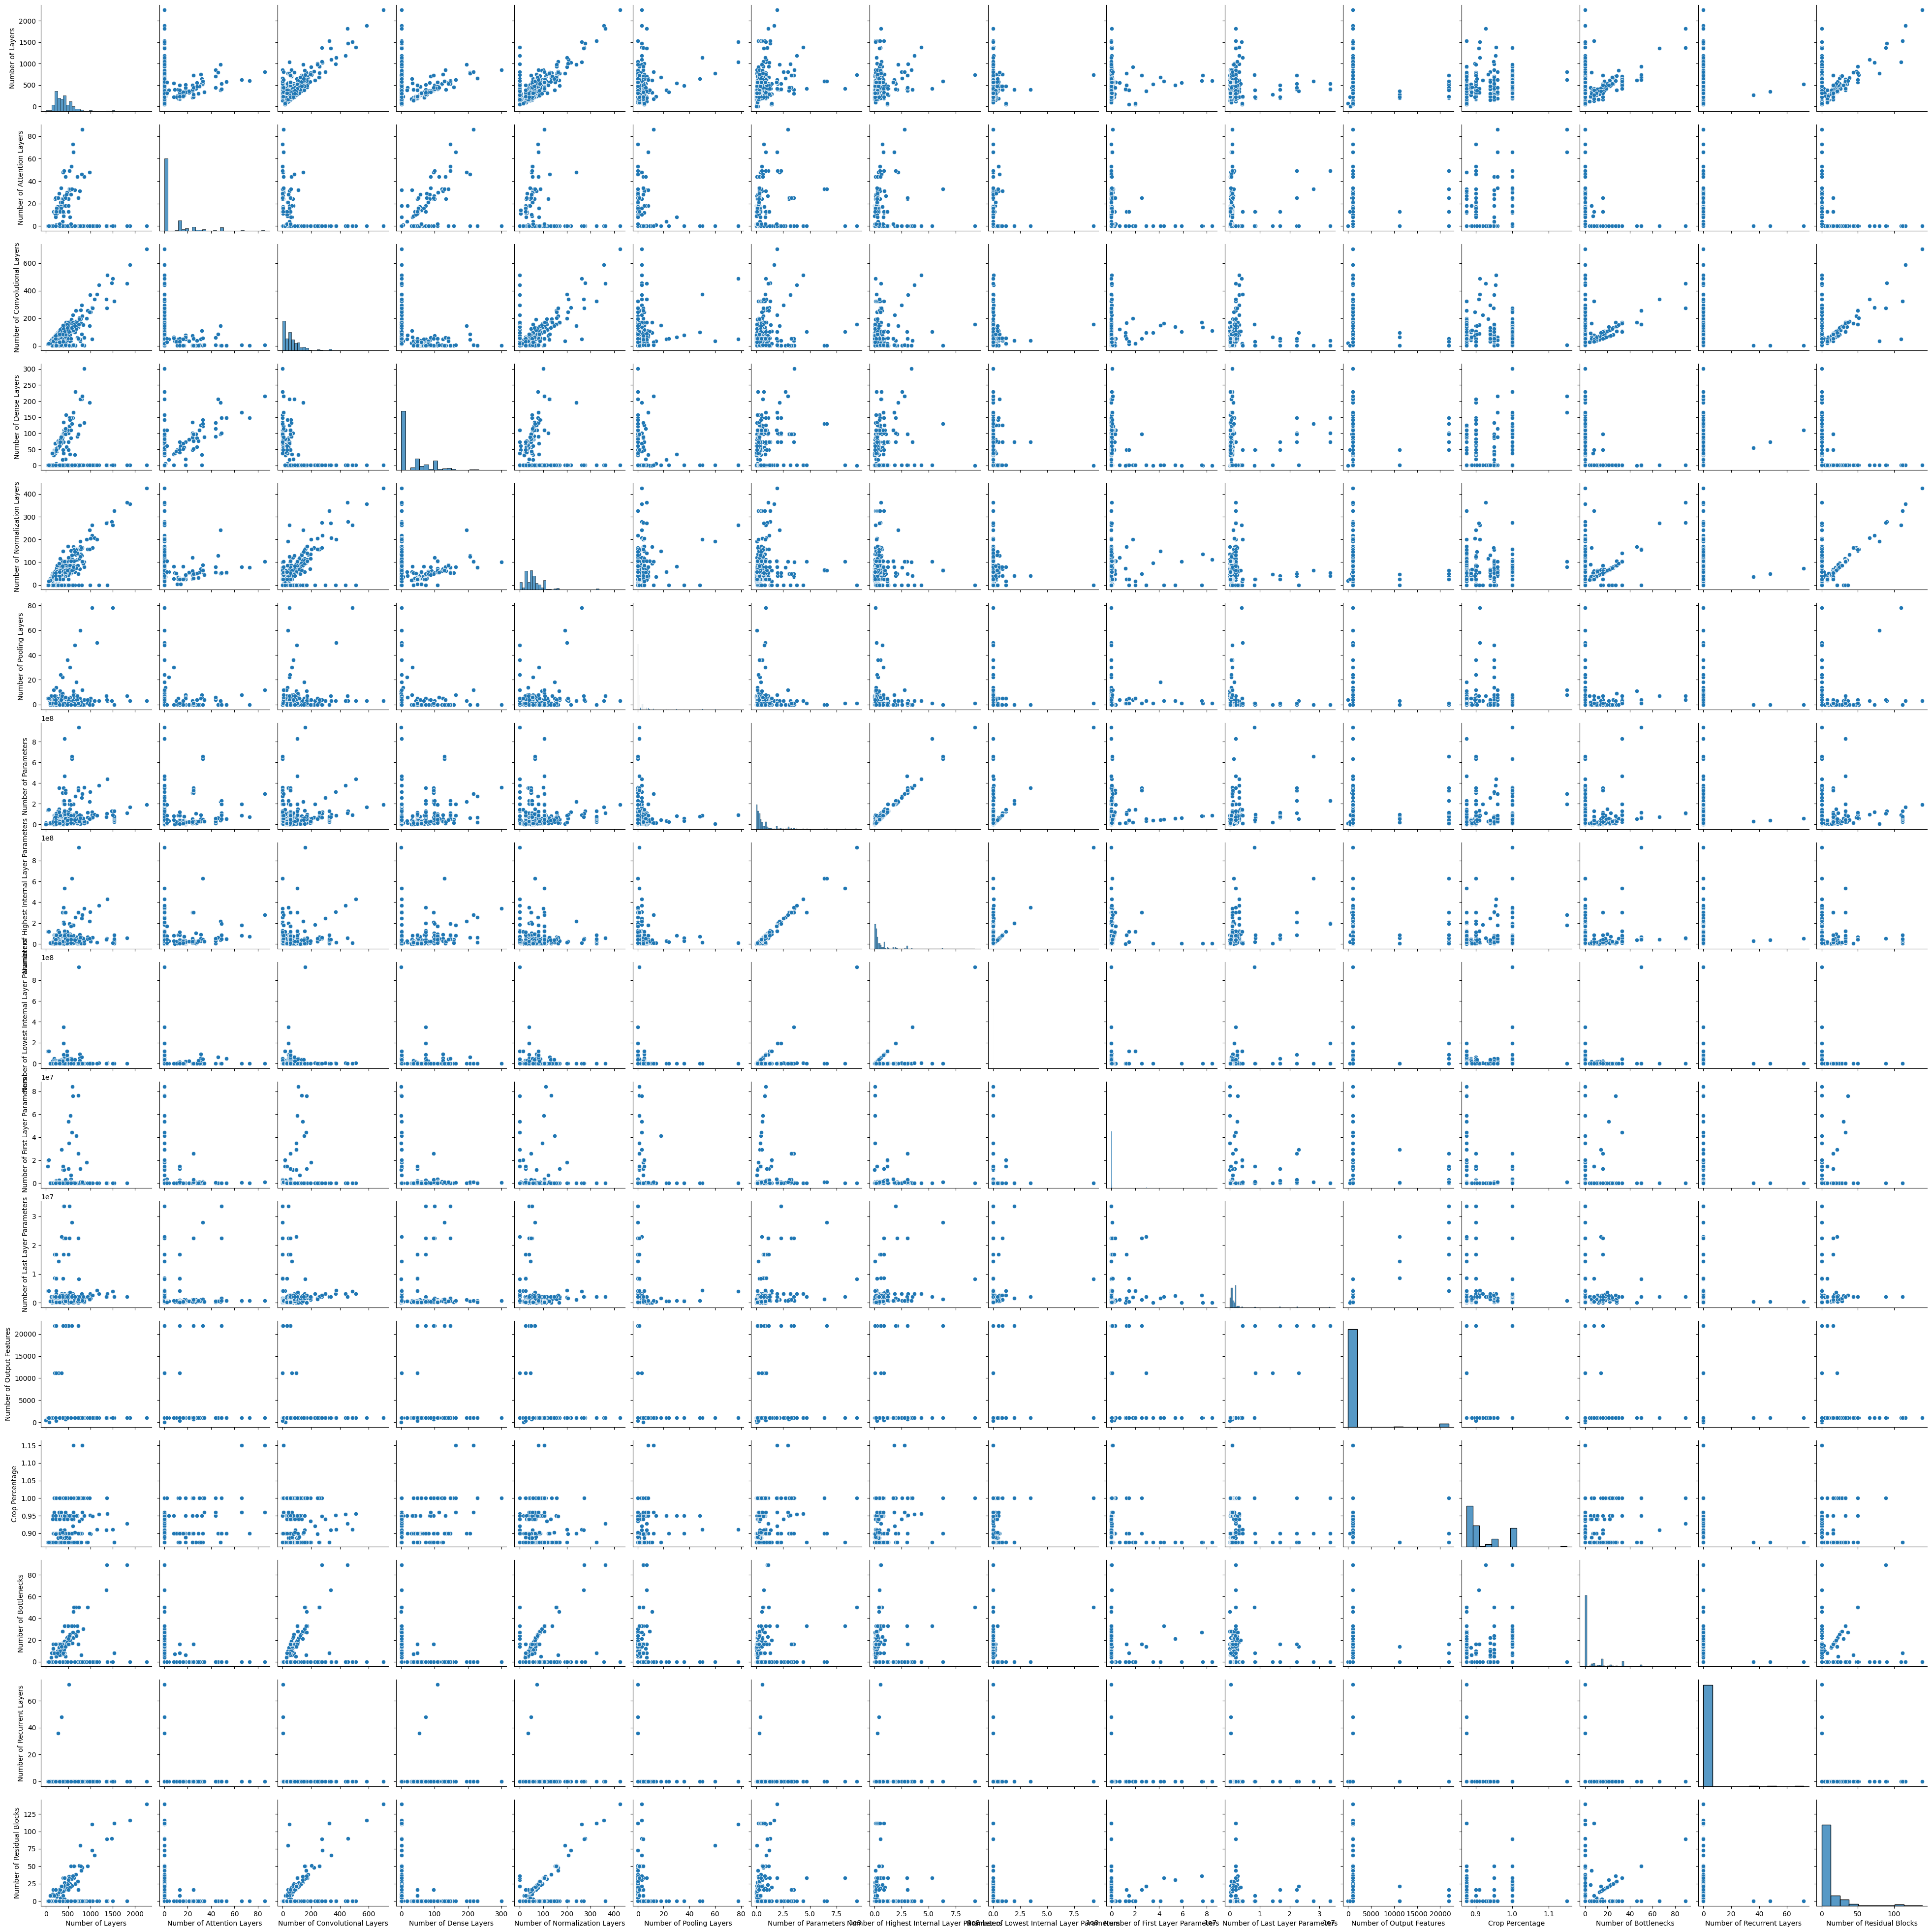

In [26]:
# plot the scatterplot matrix of continuous attributes
sns.pairplot(models_summaries_all_clean[attribute_continuous_columns_sorted])
# plt.suptitle("Scatterplot Matrix of continuous Attributes")
plt.savefig(f'{folder_save_plot}/continuous_attributes_scatterplot_matrix.png')
plt.show()

## Correlation matrix (Heatmap) of continuous attributes

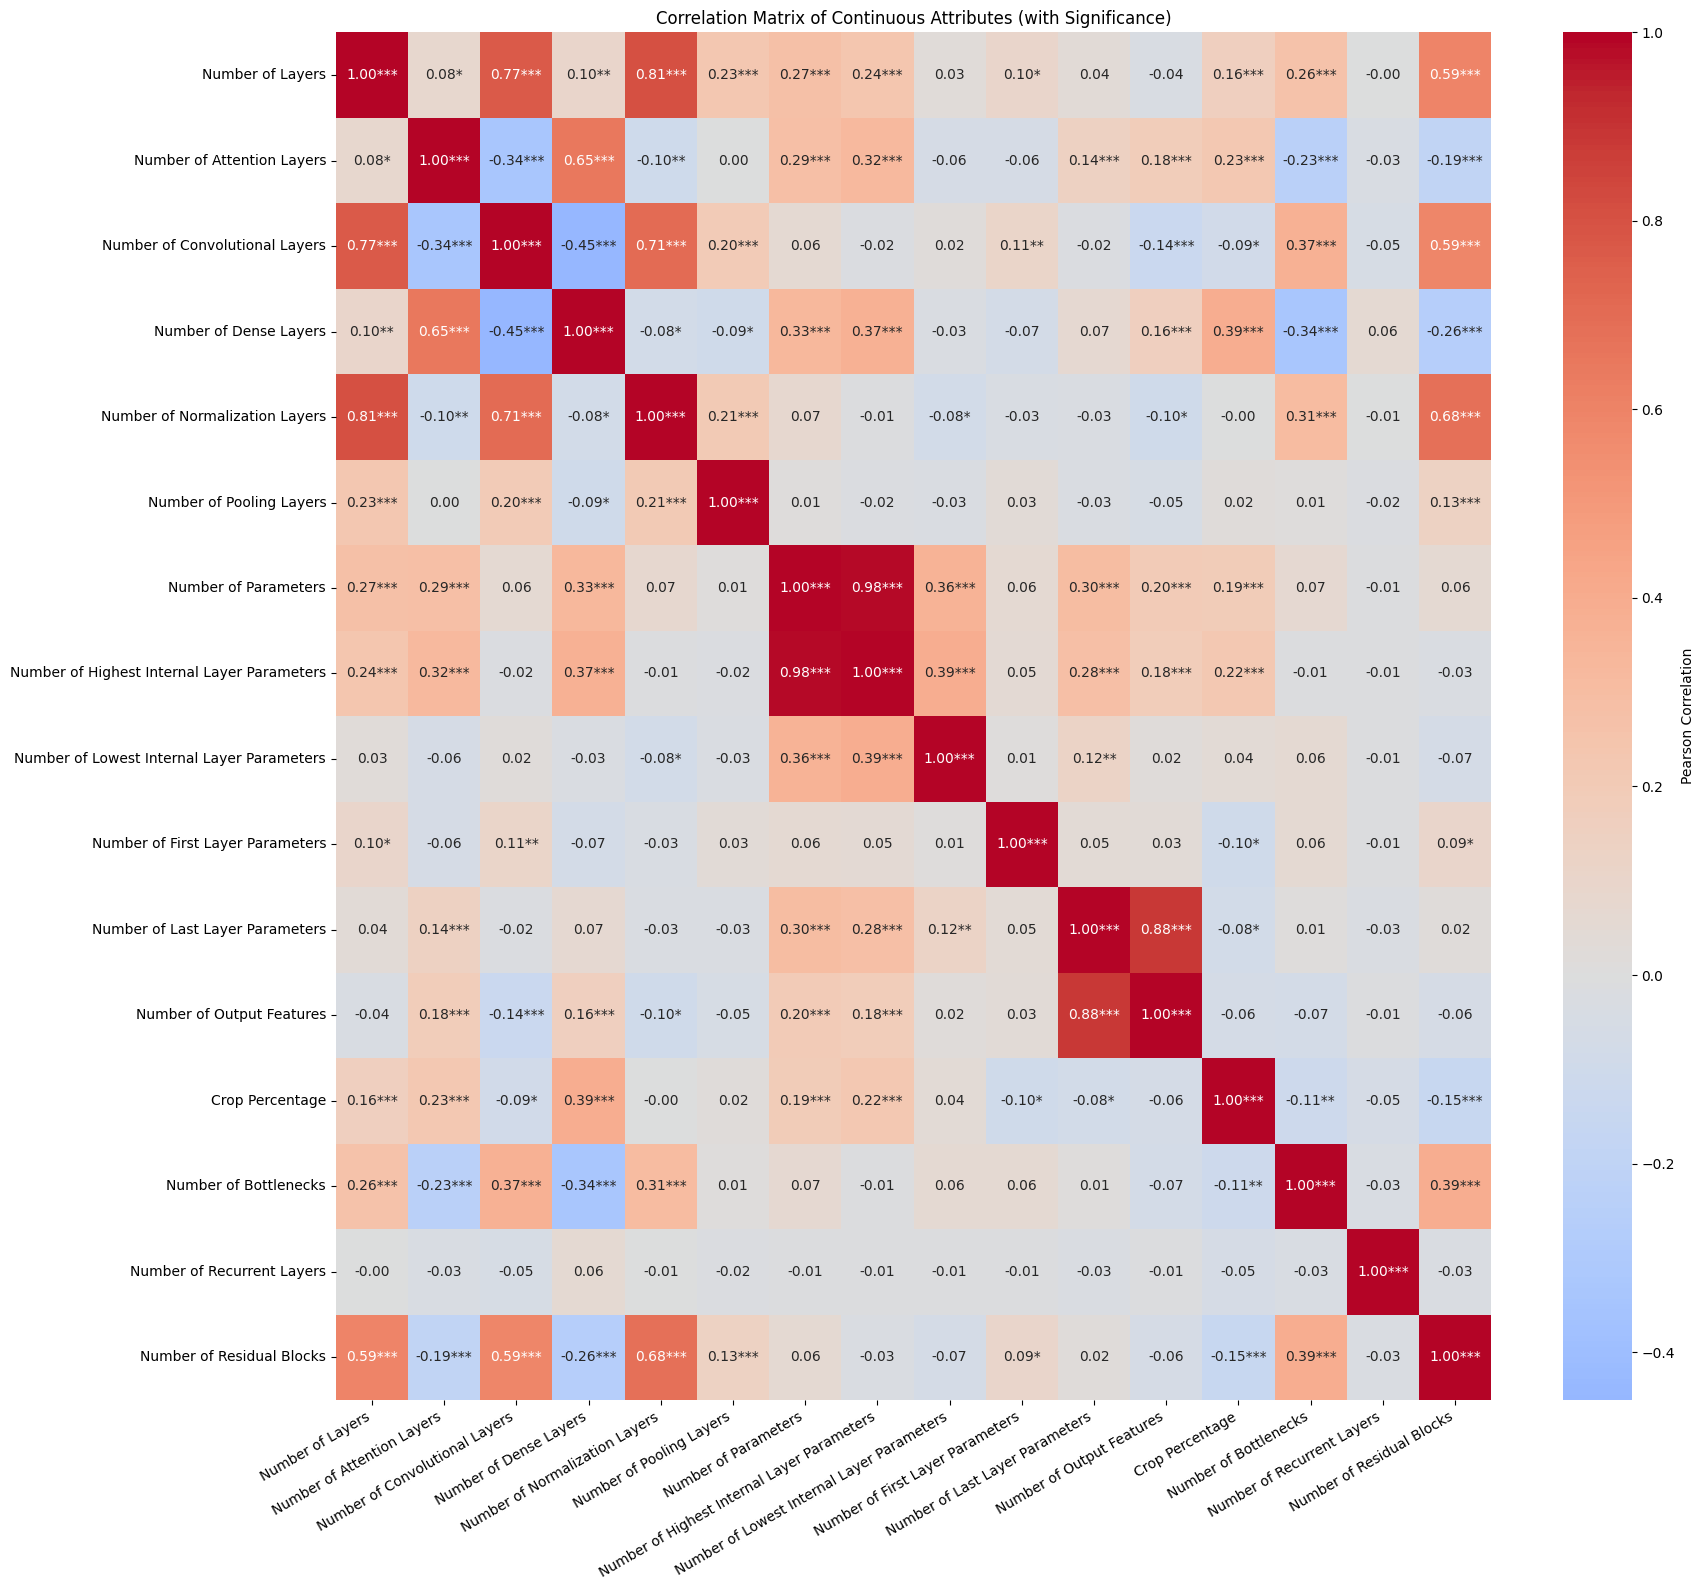

Highly correlated attribute pairs (|r| > 0.8 and p < 0.05):
    Number of Normalization Layers and Number of Layers are correlated with r = 0.81, p = 1.6e-158
    Number of Highest Internal Layer Parameters and Number of Parameters are correlated with r = 0.98, p = 0
    Number of Output Features and Number of Last Layer Parameters are correlated with r = 0.88, p = 1.2e-202


In [27]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute correlation and p-value matrices
corr_matrix = pd.DataFrame(index=attribute_continuous_columns_sorted, columns=attribute_continuous_columns_sorted)
pval_matrix = pd.DataFrame(index=attribute_continuous_columns_sorted, columns=attribute_continuous_columns_sorted)

for col1 in attribute_continuous_columns_sorted:
    for col2 in attribute_continuous_columns_sorted:
        x = models_summaries_all_clean[col1]
        y = models_summaries_all_clean[col2]
        valid_idx = x.dropna().index.intersection(y.dropna().index)
        if col1 == col2:
            corr_matrix.loc[col1, col2] = 1.0
            pval_matrix.loc[col1, col2] = 0.0
        else:
            r, p = pearsonr(x.loc[valid_idx], y.loc[valid_idx])
            corr_matrix.loc[col1, col2] = r
            pval_matrix.loc[col1, col2] = p

# Step 2: Annotate with significance stars
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

annot_matrix = pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns)
for i in corr_matrix.index:
    for j in corr_matrix.columns:
        r = corr_matrix.loc[i, j]
        p = pval_matrix.loc[i, j]
        annot_matrix.loc[i, j] = f"{r:.2f}{get_star(p)}"

# Step 3: Plot the correlation matrix with annotations
plt.figure(figsize=(18, 16))
sns.heatmap(
    corr_matrix.astype(float), annot=annot_matrix, fmt="", cmap="coolwarm", center=0,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Continuous Attributes (with Significance)")
plt.tight_layout()
plt.savefig(f'{folder_save_plot}/continuous_attributes_correlation_matrix_with_significance.png')
plt.show()

# Step 4: Print the list of highly correlated attribute pairs (|r| > 0.8 and p < 0.05)
correlated_attributes_continuous = []
threshold_r = 0.8
threshold_p = 0.05

print(f"Highly correlated attribute pairs (|r| > {threshold_r} and p < {threshold_p}):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        p = pval_matrix.iloc[i, j]
        if abs(r) > threshold_r and p < threshold_p:
            colname = corr_matrix.columns[i]
            rowname = corr_matrix.index[j]
            if colname not in correlated_attributes_continuous:
                correlated_attributes_continuous.append(colname)
            if rowname not in correlated_attributes_continuous:
                correlated_attributes_continuous.append(rowname)
            print(f"    {colname} and {rowname} are correlated with r = {r:.2f}, p = {p:.2g}")

## Calculate VIF for each continuous attribute


Variance Inflation Factor (VIF):
                                     Attributes        VIF
7   Number of Highest Internal Layer Parameters  18.671561
6                          Number of Parameters  18.218869
0                              Number of Layers  10.188654
2                Number of Convolutional Layers   8.693441
10              Number of Last Layer Parameters   5.295672
11                    Number of Output Features   5.189319
3                        Number of Dense Layers   4.626285
4                Number of Normalization Layers   4.080466
15                    Number of Residual Blocks   2.288503
1                    Number of Attention Layers   1.971821
13                        Number of Bottlenecks   1.397042
8    Number of Lowest Internal Layer Parameters   1.304926
12                              Crop Percentage   1.275757
5                      Number of Pooling Layers   1.120701
9              Number of First Layer Parameters   1.084061
14                   N

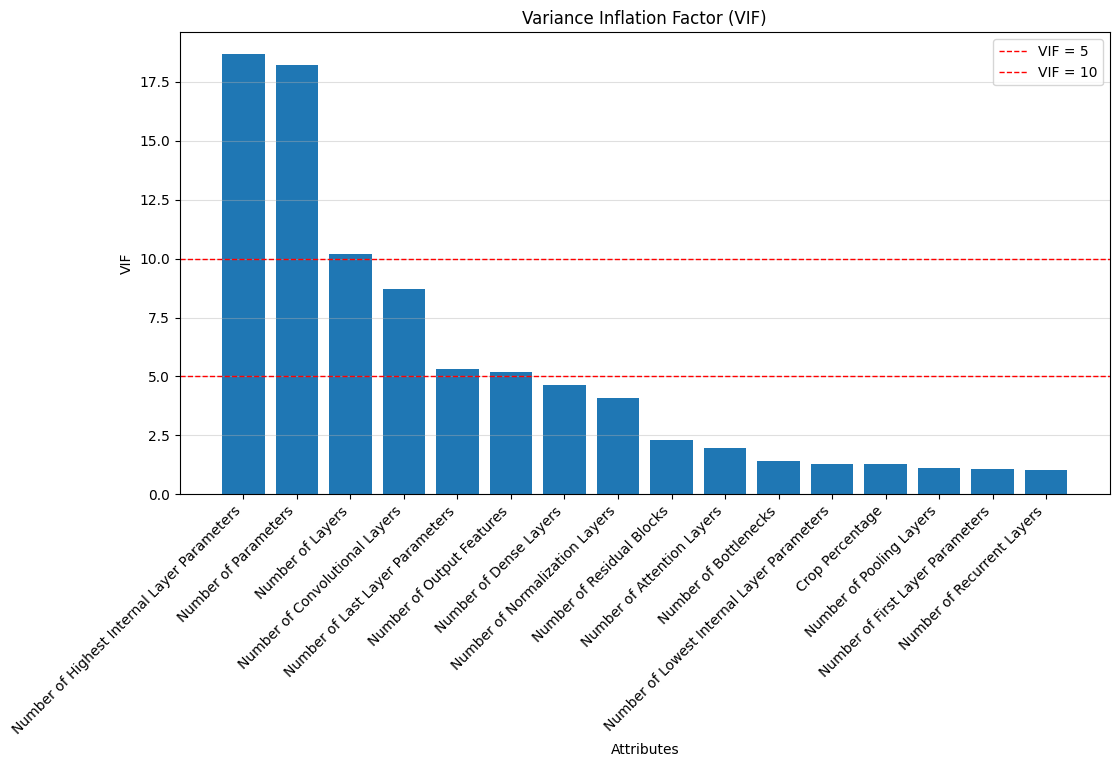


Attributes with VIF greater than 10:
                                    Attributes        VIF
7  Number of Highest Internal Layer Parameters  18.671561
6                         Number of Parameters  18.218869
0                             Number of Layers  10.188654

Attributes with VIF greater than 5:
                                     Attributes        VIF
7   Number of Highest Internal Layer Parameters  18.671561
6                          Number of Parameters  18.218869
0                              Number of Layers  10.188654
2                Number of Convolutional Layers   8.693441
10              Number of Last Layer Parameters   5.295672
11                    Number of Output Features   5.189319


In [28]:
# Standardize the continuous attributes
Xs_continuous = StandardScaler().fit_transform(models_summaries_all_clean[attribute_continuous_columns_sorted])

# Ensure there are no NaN or infinite values in the standardized data
Xs_continuous = np.nan_to_num(Xs_continuous, nan=0.0, posinf=0.0, neginf=0.0)

# Calculate the VIF (Variance Inflation Factor) for each continuous attribute
vif_data = pd.DataFrame({
    "Attributes": attribute_continuous_columns_sorted,
    "VIF": [variance_inflation_factor(Xs_continuous, i) for i in range(Xs_continuous.shape[1])]
})

# sort the VIF from largest to smallest
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
print(vif_data)

# plot the VIF
plt.figure(figsize=(12, 6))
plt.bar(vif_data["Attributes"], vif_data["VIF"])
plt.xlabel("Attributes")
plt.ylabel("VIF")
plt.title("Variance Inflation Factor (VIF)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.4)
# draw a line of VIF = 5 and VIF = 10
plt.axhline(y=5, color='r', linestyle='--', linewidth=1, label='VIF = 5')
plt.axhline(y=10, color='r', linestyle='--', linewidth=1, label='VIF = 10')
plt.legend()
plt.savefig(f'{folder_save_plot}/continuous_attributes_vif.png')
plt.show()


# Print list of attributes with VIF above threshold
threshold = 10
high_vif_attributes = vif_data[vif_data["VIF"] > threshold]

print(f"\nAttributes with VIF greater than {threshold}:")
print(high_vif_attributes)


# Print list of attributes with VIF above threshold
threshold = 5
high_vif_attributes = vif_data[vif_data["VIF"] > threshold]

print(f"\nAttributes with VIF greater than {threshold}:")
print(high_vif_attributes)

## Use PCA to find the most important continuous attributes

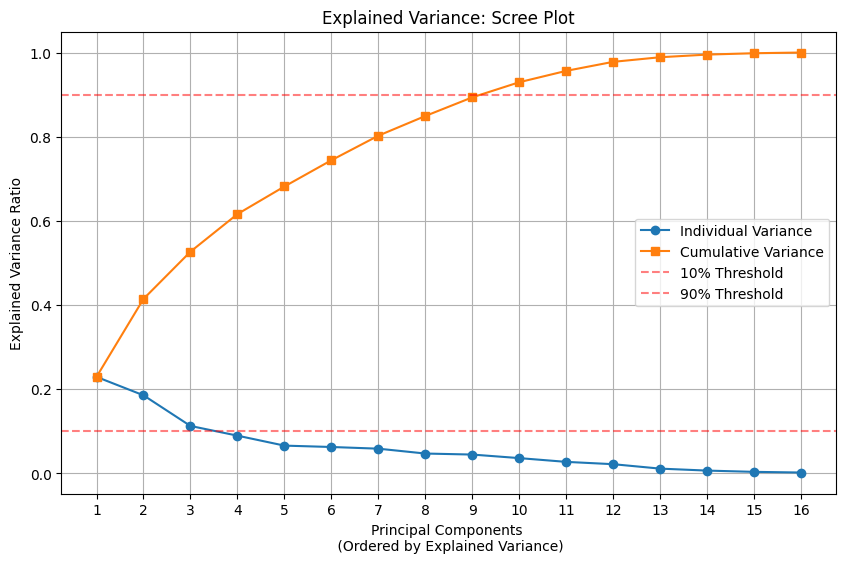

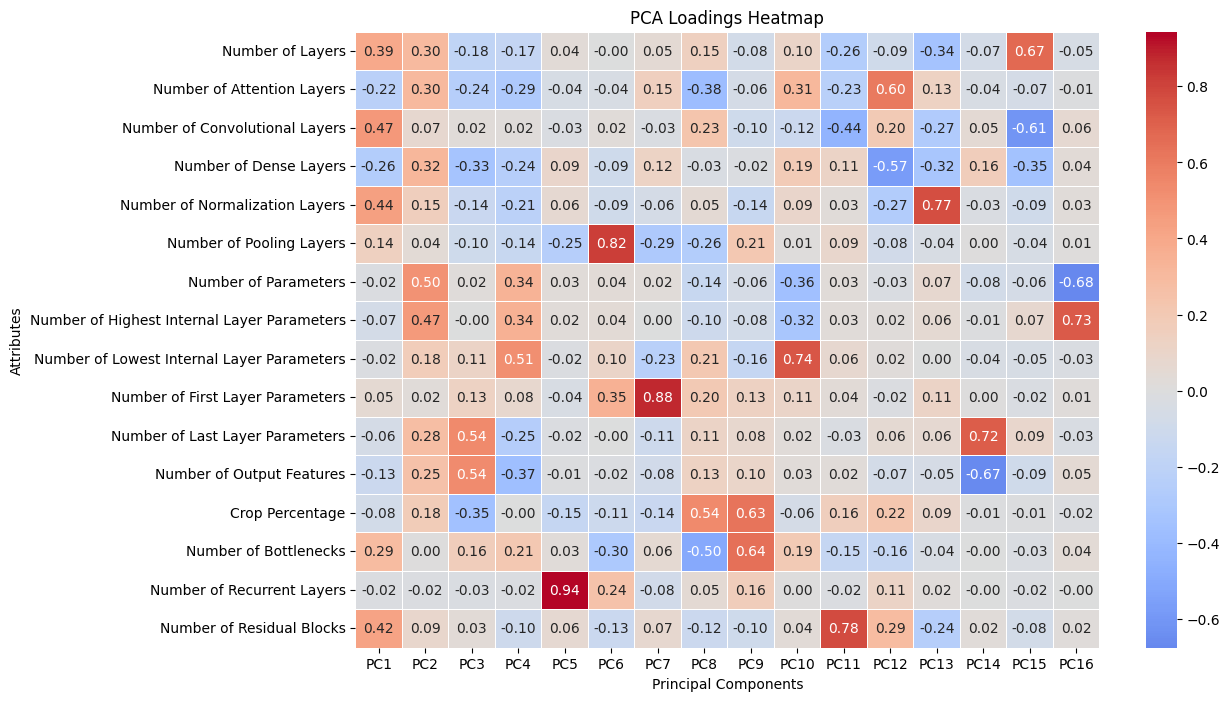

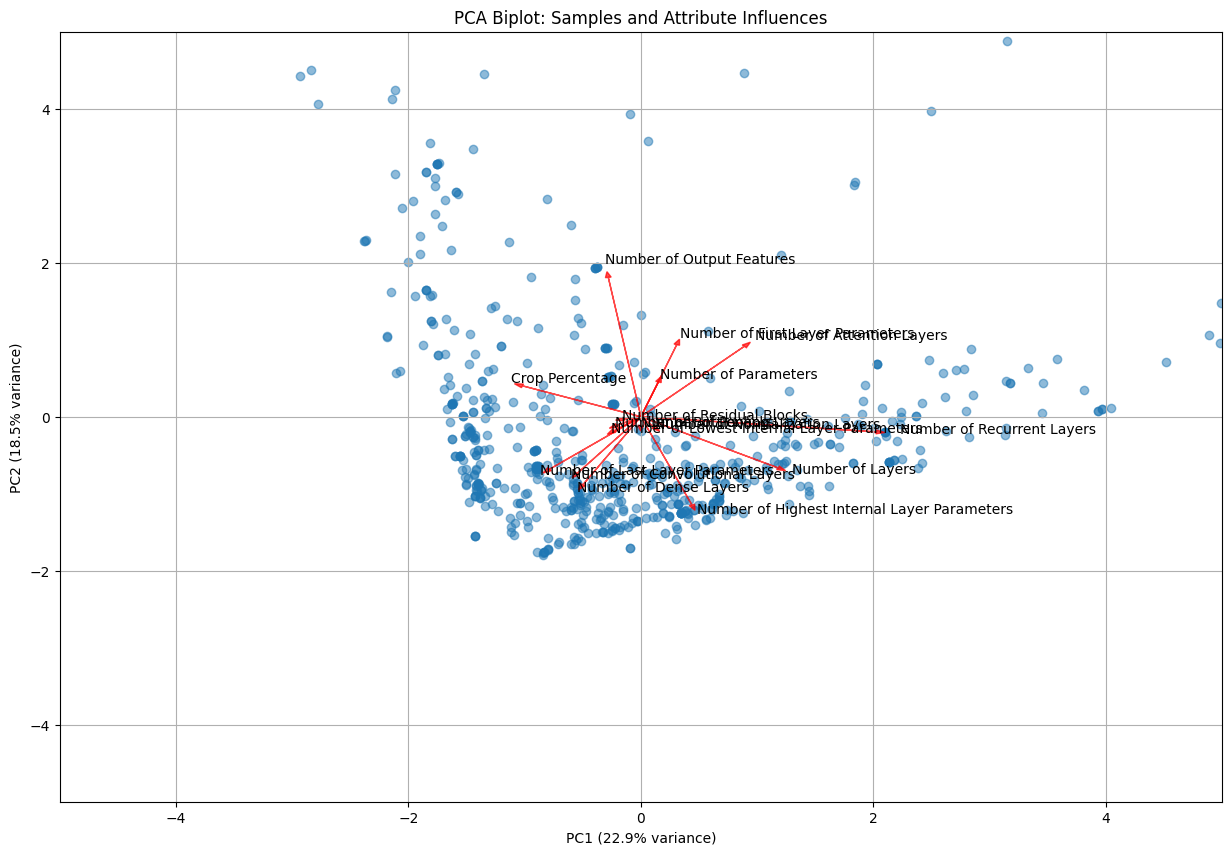


PCA Summary:
- Total number of continuous attributes analyzed: 16
- Number of PCs needed to explain at least 90% of total variance: 10
- Variance explained by the first 5 PCs:
  • PC1: 22.90%
  • PC2: 18.52%
  • PC3: 11.24%
  • PC4: 8.93%
  • PC5: 6.56%

Top 5 attributes contributing to PC1:
Number of Convolutional Layers    0.474299
Number of Normalization Layers    0.435339
Number of Residual Blocks         0.419469
Number of Layers                  0.393236
Number of Bottlenecks             0.288038
Name: PC1, dtype: float64

Top 5 attributes contributing to PC2:
Number of Parameters                           0.504841
Number of Highest Internal Layer Parameters    0.467896
Number of Dense Layers                         0.319423
Number of Attention Layers                     0.304678
Number of Layers                               0.296501
Name: PC2, dtype: float64


In [29]:
# PCA

pca = PCA()
pca_result = pca.fit_transform(Xs_continuous)

# explained variance ratio: how much variance each principal component explains 
explained_variance_ratio = pca.explained_variance_ratio_ # PC1 to n explains the most to the least variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# goal is to use fewer PCs to capture most of the variances


# Explained variance plot (Scree Plot)

# plot the explained variance ratio (individual and cumulative) of each principal component
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 
         marker='o', linestyle='-', label='Individual Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='s', linestyle='-', label='Cumulative Variance')
plt.axhline(y=0.1, linestyle='--', label='10% Threshold', color='red', alpha=0.5)
plt.axhline(y=0.9, linestyle='--', label='90% Threshold', color='red', alpha=0.5)
plt.xlabel('Principal Components \n (Ordered by Explained Variance)')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance: Scree Plot')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend(loc='best')
plt.grid(True)
plt.savefig(f'{folder_save_plot}/continuous_attributes_pca_scree_plot.png')
plt.show()




# PCA Loadings

# show how much each attribute contributes to each principal component
pca_loadings = pd.DataFrame(
    pca.components_,
    columns=attribute_continuous_columns_sorted,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)
# visualize the loadings
plt.figure(figsize=(12, 8))
sns.heatmap(pca_loadings.T, 
            annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f", center=0
            )
plt.title('PCA Loadings Heatmap')
plt.xlabel('Principal Components')
plt.ylabel('Attributes')
plt.savefig(f'{folder_save_plot}/continuous_attributes_pca_loadings_heatmap.png')
plt.show()



# PCA Biplot
# visualize samples and attributes together
plt.figure(figsize=(15, 10))
x_scores = pca_result[:, 0]
y_scores = pca_result[:, 1]
plt.scatter(x_scores, y_scores, alpha=0.5, label='')

for i, var in enumerate(attribute_continuous_columns_sorted):
    plt.arrow(0, 0, pca_loadings.iloc[i, 0]*3, pca_loadings.iloc[i, 1]*3,
              color='red', alpha=0.7, head_width=0.05)
    plt.text(pca_loadings.iloc[i, 0]*3.3, pca_loadings.iloc[i, 1]*3.3, var, fontsize=10)

plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title('PCA Biplot: Samples and Attribute Influences')
plt.grid(True)
plt.savefig(f'{folder_save_plot}/continuous_attributes_pca_biplot.png')
plt.show()



# Calculate the number of PCs to capture 90% of the variance
threshold_cum_variance = 0.9
num_components = np.argmax(cumulative_variance >= threshold_cum_variance) + 1

# Final summary
print("\nPCA Summary:")
print(f"- Total number of continuous attributes analyzed: {len(attribute_continuous_columns_sorted)}")
print(f"- Number of PCs needed to explain at least 90% of total variance: {num_components}")
print("- Variance explained by the first 5 PCs:")
for i in range(min(5, len(explained_variance_ratio))):
    print(f"  • PC{i+1}: {explained_variance_ratio[i]*100:.2f}%")

# Print top contributing attributes to PC1 and PC2
top_n = 5
print(f"\nTop {top_n} attributes contributing to PC1:")
print(pca_loadings.loc['PC1'].abs().sort_values(ascending=False).head(top_n))

print(f"\nTop {top_n} attributes contributing to PC2:")
print(pca_loadings.loc['PC2'].abs().sort_values(ascending=False).head(top_n))

# 3. Analysis on Categorical Attributes

In [30]:
print(attribute_categorical_columns)

attribute_categorical_columns_sorted = attribute_categorical_columns.copy()

# remove unuseful columns
attribute_categorical_columns_sorted.remove("Model")

# sort the categorical attributes alphabetically
attribute_categorical_columns_sorted.sort()

print(attribute_categorical_columns_sorted)

['Training Dataset', 'Origin', 'Model', 'Architecture Family', 'Training Type', 'Primary Application', 'Key Distinguishing Feature', 'Most Common Pooling Type', 'Most Common Activation Function']
['Architecture Family', 'Key Distinguishing Feature', 'Most Common Activation Function', 'Most Common Pooling Type', 'Origin', 'Primary Application', 'Training Dataset', 'Training Type']


## Cramér's V with Chi-square significance for categorical attributes

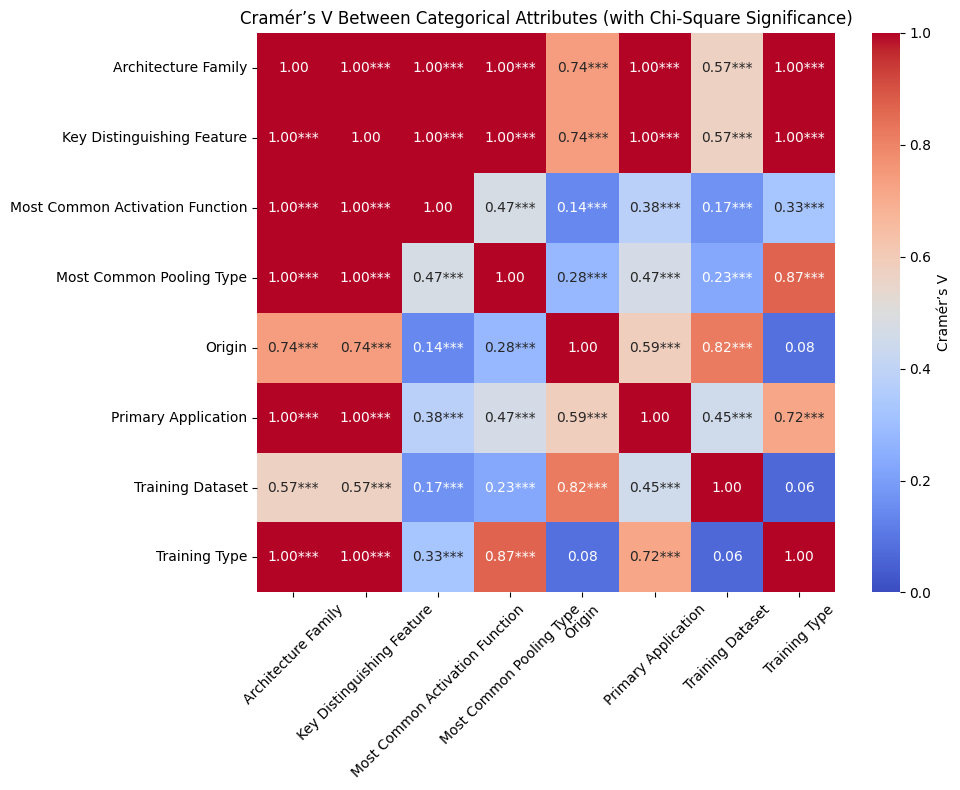


Categorical Attribute Association Summary (Cramér’s V):
- Total attribute pairs evaluated: 28
- Pairs with strong association (Cramér’s V > 0.7): 14
- Pairs with statistically significant association (p < 0.05): 26

Top 5 most strongly associated categorical attribute pairs:
                    Attribute 1                Attribute 2  Cramér's V       p-value
     Key Distinguishing Feature        Architecture Family         1.0  0.000000e+00
Most Common Activation Function        Architecture Family         1.0 6.335417e-279
       Most Common Pooling Type        Architecture Family         1.0  0.000000e+00
            Primary Application        Architecture Family         1.0  0.000000e+00
            Primary Application Key Distinguishing Feature         1.0  0.000000e+00


In [31]:
# Create matrices for Cramér’s V and p-values
cramer_matrix = pd.DataFrame(index=attribute_categorical_columns_sorted, columns=attribute_categorical_columns_sorted, dtype=float)
pval_matrix = pd.DataFrame(index=attribute_categorical_columns_sorted, columns=attribute_categorical_columns_sorted, dtype=float)
annot_matrix = pd.DataFrame(index=attribute_categorical_columns_sorted, columns=attribute_categorical_columns_sorted, dtype=str)

def cramers_v_with_p(x, y):
    table = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    cramer = np.sqrt(chi2 / (n * (min(k - 1, r - 1))))
    return cramer, p

def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for col1 in attribute_categorical_columns_sorted:
    for col2 in attribute_categorical_columns_sorted:
        if col1 == col2:
            cramer_matrix.loc[col1, col2] = 1.0
            pval_matrix.loc[col1, col2] = 0.0
            annot_matrix.loc[col1, col2] = "1.00"
        else:
            x = models_summaries_all_clean[col1].dropna()
            y = models_summaries_all_clean[col2].dropna()
            valid_idx = x.index.intersection(y.index)
            cramer, p = cramers_v_with_p(x.loc[valid_idx], y.loc[valid_idx])
            cramer_matrix.loc[col1, col2] = cramer
            pval_matrix.loc[col1, col2] = p
            annot_matrix.loc[col1, col2] = f"{cramer:.2f}{get_star(p)}"

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix.astype(float), annot=annot_matrix, fmt='', 
            cmap='coolwarm', vmin=0, vmax=1, cbar_kws={'label': "Cramér’s V"})
plt.title("Cramér’s V Between Categorical Attributes (with Chi-Square Significance)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{folder_save_plot}/categorical_attributes_cramers_v_with_significance.png')
plt.show()


# Final summary of categorical attribute associations
print("\nCategorical Attribute Association Summary (Cramér’s V):")

# Flatten and filter significant associations
assoc_list = []
threshold_v = 0.7
threshold_p = 0.05

for i in range(len(cramer_matrix.columns)):
    for j in range(i):
        attr1 = cramer_matrix.columns[i]
        attr2 = cramer_matrix.index[j]
        v = cramer_matrix.iloc[i, j]
        p = pval_matrix.iloc[i, j]
        if not pd.isna(v):
            assoc_list.append((attr1, attr2, v, p))

# Convert to DataFrame for sorting
assoc_df = pd.DataFrame(assoc_list, columns=["Attribute 1", "Attribute 2", "Cramér's V", "p-value"])
assoc_df = assoc_df.sort_values(by="Cramér's V", ascending=False)

# Print summary
n_total = len(assoc_df)
n_strong = len(assoc_df[assoc_df["Cramér's V"] > threshold_v])
n_significant = len(assoc_df[assoc_df["p-value"] < threshold_p])

print(f"- Total attribute pairs evaluated: {n_total}")
print(f"- Pairs with strong association (Cramér’s V > {threshold_v}): {n_strong}")
print(f"- Pairs with statistically significant association (p < {threshold_p}): {n_significant}")

print(f"\nTop 5 most strongly associated categorical attribute pairs:")
print(assoc_df.head(5).to_string(index=False))

# 4. Analysis on Binary Attributes

In [32]:
print(attribute_binary_columns)

attribute_binary_columns_sorted = attribute_binary_columns.copy()

# remove unuseful columns
# attribute_binary_columns_sorted = attribute_binary_columns_sorted.remove("")

# sort the categorical attributes alphabetically
attribute_binary_columns_sorted.sort()

print(attribute_binary_columns_sorted)

['Has Convolutional Layers', 'Has Residual Blocks', 'Has Dense Layers', 'Has Bottlenecks', 'Has Skip Connections', 'Has Attention Layers', 'Tokenized', 'Transformer']
['Has Attention Layers', 'Has Bottlenecks', 'Has Convolutional Layers', 'Has Dense Layers', 'Has Residual Blocks', 'Has Skip Connections', 'Tokenized', 'Transformer']


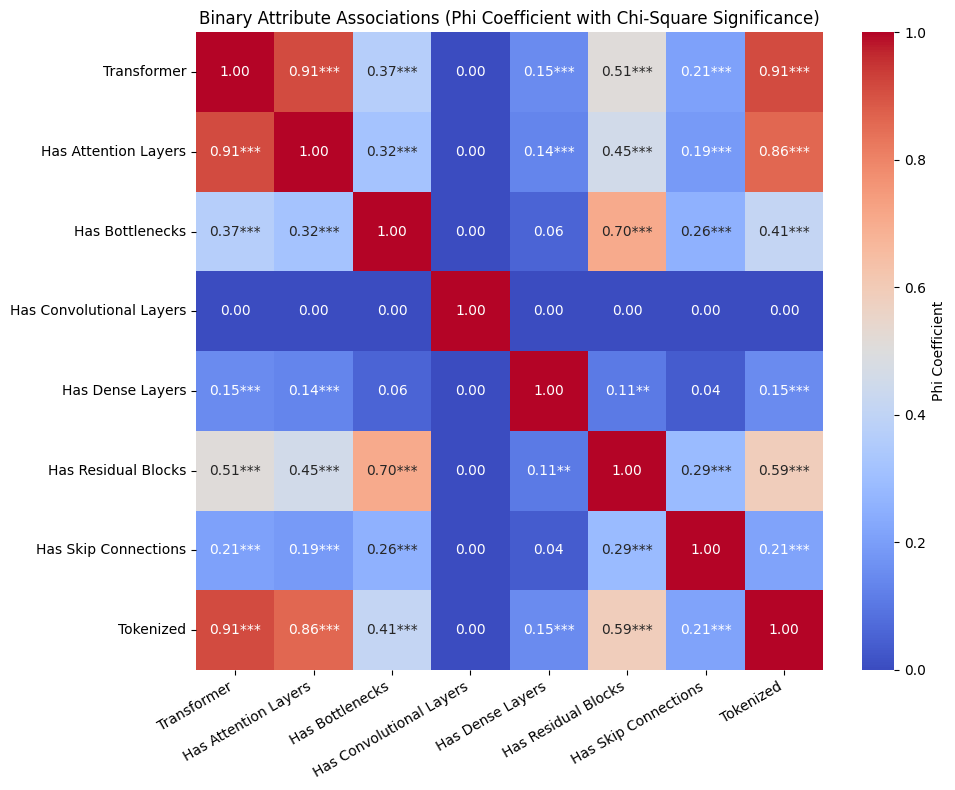


Binary Attribute Association Summary (Phi Coefficient):
- Total binary attribute pairs evaluated: 28
- Pairs with strong association (Phi > 0.7): 4
- Pairs with statistically significant association (p < 0.05): 19

Top 5 most strongly associated binary attribute pairs:
         Attribute 1          Attribute 2  Phi Coefficient       p-value
           Tokenized          Transformer         0.913226 2.930416e-124
Has Attention Layers          Transformer         0.911578 8.090921e-124
           Tokenized Has Attention Layers         0.859396 2.875464e-110
 Has Residual Blocks      Has Bottlenecks         0.703629  1.507783e-74
           Tokenized  Has Residual Blocks         0.587356  1.680774e-52


In [33]:
# Get binary columns
binary_cols = attribute_table.query("`Attribute Type` == 'Binary'")["Attribute"].tolist()

# Initialize matrices
phi_matrix = pd.DataFrame(index=binary_cols, columns=binary_cols, dtype=float)
pval_matrix = pd.DataFrame(index=binary_cols, columns=binary_cols, dtype=float)
annot_matrix = pd.DataFrame(index=binary_cols, columns=binary_cols, dtype=str)

def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Compute pairwise associations
for col1 in binary_cols:
    for col2 in binary_cols:
        if col1 == col2:
            phi_matrix.loc[col1, col2] = 1.0
            pval_matrix.loc[col1, col2] = 0.0
            annot_matrix.loc[col1, col2] = "1.00"
        else:
            table = pd.crosstab(models_summaries_all_clean[col1], models_summaries_all_clean[col2])
            chi2, p, _, _ = chi2_contingency(table)
            n = table.sum().sum()
            phi = np.sqrt(chi2 / n)
            phi_matrix.loc[col1, col2] = phi
            pval_matrix.loc[col1, col2] = p
            annot_matrix.loc[col1, col2] = f"{phi:.2f}{get_star(p)}"

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    phi_matrix.astype(float), annot=annot_matrix, fmt='', cmap='coolwarm', vmin=0, vmax=1,
    cbar_kws={'label': "Phi Coefficient"}
)
plt.title("Binary Attribute Associations (Phi Coefficient with Chi-Square Significance)")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{folder_save_plot}/binary_attributes_phi_with_significance.png')
plt.show()


# Final summary of binary attribute associations
print("\nBinary Attribute Association Summary (Phi Coefficient):")

# Flatten and filter the results
assoc_list = []
threshold_phi = 0.7
threshold_p = 0.05

for i in range(len(phi_matrix.columns)):
    for j in range(i):
        attr1 = phi_matrix.columns[i]
        attr2 = phi_matrix.index[j]
        phi = phi_matrix.iloc[i, j]
        p = pval_matrix.iloc[i, j]
        if not pd.isna(phi):
            assoc_list.append((attr1, attr2, phi, p))

# Convert to DataFrame for sorting
assoc_df = pd.DataFrame(assoc_list, columns=["Attribute 1", "Attribute 2", "Phi Coefficient", "p-value"])
assoc_df = assoc_df.sort_values(by="Phi Coefficient", ascending=False)

# Print summary
n_total = len(assoc_df)
n_strong = len(assoc_df[assoc_df["Phi Coefficient"] > threshold_phi])
n_significant = len(assoc_df[assoc_df["p-value"] < threshold_p])

print(f"- Total binary attribute pairs evaluated: {n_total}")
print(f"- Pairs with strong association (Phi > {threshold_phi}): {n_strong}")
print(f"- Pairs with statistically significant association (p < {threshold_p}): {n_significant}")

print(f"\nTop 5 most strongly associated binary attribute pairs:")
print(assoc_df.head(5).to_string(index=False))

# 5. Cross-Analysis between three types of attributes

## Continuous x Categorical

In [41]:
from scipy.stats import f_oneway

anova_results = []

for cat_col in attribute_table.query("`Attribute Type` == 'Categorical'")["Attribute"]:
    for cont_col in attribute_table.query("`Attribute Type` == 'Continuous'")["Attribute"]:
        df_pair = models_summaries_all_clean[[cat_col, cont_col]].dropna()
        if df_pair[cat_col].nunique() > 1:
            # Get value groups by category
            grouped = df_pair.groupby(cat_col)[cont_col].apply(list)
            if len(grouped) > 1:
                try:
                    f_stat, p = f_oneway(*grouped)
                    anova_results.append((cat_col, cont_col, f_stat, p))
                except Exception as e:
                    print(f"Skipping {cat_col} × {cont_col}: {e}")

anova_df = pd.DataFrame(anova_results, columns=["Categorical Attribute", "Continuous Attribute", "F-Statistic", "p-value"])
anova_df = anova_df.sort_values(by="F-Statistic", ascending=False)

# print top results
print("\nContinuous × Categorical Relationships (ANOVA) Top F-Statistics:")
print(anova_df.to_string(index=False))

# save the results
anova_df.to_csv(f'{folder_save}/cross_attributes_con_cat_anova.csv', index=False)

/home/pengy3/Desktop/venv_yinuo/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/home/pengy3/Desktop/venv_yinuo/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if _f_oneway_is_too_small(samples):
/home/pengy3/Desktop/venv_yinuo/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if _f_oneway_is_too_small(samples):
/home/pengy3/Desktop/venv_yinuo/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if _f_oneway_is_too_small(s


Continuous × Categorical Relationships (ANOVA) Top F-Statistics:
          Categorical Attribute                        Continuous Attribute  F-Statistic       p-value
     Key Distinguishing Feature                                   Year Made          inf  0.000000e+00
            Architecture Family                                   Year Made          inf  0.000000e+00
               Training Dataset                   Number of Output Features  3196.162312  0.000000e+00
               Training Dataset             Number of Last Layer Parameters   730.959225 1.771644e-201
       Most Common Pooling Type                                   Year Made   162.989920 9.575679e-139
Most Common Activation Function                                   Year Made   144.556555  6.308736e-72
Most Common Activation Function                  Number of Attention Layers   137.913502  1.610297e-69
Most Common Activation Function                      Number of Dense Layers   118.263131  2.041515e-61
       

/home/pengy3/Desktop/venv_yinuo/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


## Continuous x Binary

In [45]:
# Point-biserial correlation

from scipy.stats import pointbiserialr
# Prepare result storage
pb_results = []

for binary_col in attribute_table.query("`Attribute Type` == 'Binary'")["Attribute"]:
    for cont_col in attribute_table.query("`Attribute Type` == 'Continuous'")["Attribute"]:
        df_pair = models_summaries_all_clean[[binary_col, cont_col]].dropna()
        if df_pair[binary_col].nunique() == 2:
            r, p = pointbiserialr(df_pair[binary_col], df_pair[cont_col])
            pb_results.append((binary_col, cont_col, r, p))

# Convert to DataFrame and sort
pb_df = pd.DataFrame(pb_results, columns=["Binary Attribute", "Continuous Attribute", "Correlation", "p-value"])
pb_df = pb_df.sort_values(by="Correlation", key=abs, ascending=False)

# # Plot boxplots for top 5 strongest correlations
# for _, row in pb_df.head(5).iterrows():
#     binary_col, cont_col = row["Binary Attribute"], row["Continuous Attribute"]
#     sns.boxplot(x=binary_col, y=cont_col, data=models_summaries_all_clean)
#     plt.title(f"{cont_col} by {binary_col}")
#     plt.tight_layout()
#     plt.savefig(f'{folder_save_plot}/boxplot_{cont_col}_by_{binary_col}.png')

#     plt.show()

print("\nContinuous × Binary Attribute Relationships (Point-Biserial Correlation):")
print(pb_df.to_string(index=False))

# save the results
pb_df.to_csv(f'{folder_save}/cross_attribute_con_bin_point_biserial_cor.csv', index=False)




Continuous × Binary Attribute Relationships (Point-Biserial Correlation):
    Binary Attribute                        Continuous Attribute  Correlation       p-value
           Tokenized                      Number of Dense Layers     0.712111 7.296045e-105
Has Attention Layers                  Number of Attention Layers     0.705061 6.061162e-102
         Transformer                      Number of Dense Layers     0.682650  3.262474e-93
         Transformer                  Number of Attention Layers     0.644812  3.960780e-80
           Tokenized                                   Year Made     0.611328  5.493361e-69
           Tokenized                  Number of Attention Layers     0.606233  1.431624e-68
         Transformer                                   Year Made     0.603124  1.010033e-66
Has Attention Layers                      Number of Dense Layers     0.594770  1.959589e-65
Has Attention Layers                                   Year Made     0.551996  5.555299e-54
 Has 

## Categorical x Binary

In [43]:
cat_bin_results = []

for cat_col in attribute_table.query("`Attribute Type` == 'Categorical'")["Attribute"]:
    for bin_col in attribute_table.query("`Attribute Type` == 'Binary'")["Attribute"]:
        df_pair = models_summaries_all_clean[[cat_col, bin_col]].dropna()
        if df_pair[cat_col].nunique() > 1 and df_pair[bin_col].nunique() == 2:
            try:
                contingency = pd.crosstab(df_pair[cat_col], df_pair[bin_col])
                chi2, p, dof, _ = chi2_contingency(contingency)
                cat_bin_results.append((cat_col, bin_col, chi2, p))
            except Exception as e:
                print(f"Skipping {cat_col} × {bin_col}: {e}")

cat_bin_df = pd.DataFrame(cat_bin_results, columns=["Categorical Attribute", "Binary Attribute", "Chi2", "p-value"])
cat_bin_df = cat_bin_df.sort_values(by="Chi2", ascending=False)

print("\nCategorical × Binary Associations (Chi-Square Test):")
print(cat_bin_df.to_string(index=False))

# save the results
cat_bin_df.to_csv(f'{folder_save}/cross_attribute_cat_bin_chi2.csv', index=False)


Categorical × Binary Associations (Chi-Square Test):
          Categorical Attribute     Binary Attribute       Chi2      p-value
            Architecture Family Has Attention Layers 674.000000 9.203755e-95
                          Model Has Skip Connections 674.000000 4.818887e-01
            Architecture Family          Transformer 674.000000 9.203755e-95
            Architecture Family  Has Residual Blocks 674.000000 9.203755e-95
            Architecture Family Has Skip Connections 674.000000 9.203755e-95
            Architecture Family            Tokenized 674.000000 9.203755e-95
            Architecture Family      Has Bottlenecks 674.000000 9.203755e-95
                          Model          Transformer 674.000000 4.818887e-01
                          Model  Has Residual Blocks 674.000000 4.818887e-01
     Key Distinguishing Feature          Transformer 674.000000 3.570538e-96
     Key Distinguishing Feature Has Attention Layers 674.000000 3.570538e-96
                      

# 6. Analysis on Test Dataset effect on Model Similarity

Familiar vs. Novel Mean Similarity: t = -2.35, p = 0.051
Images per Category vs. Mean Similarity: r = 0.29, p = 0.455


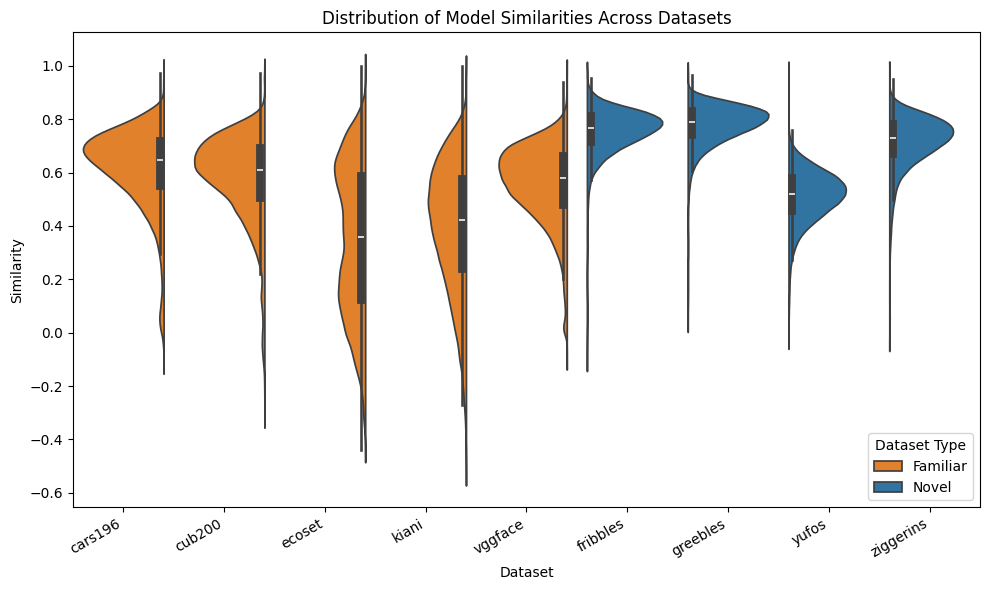

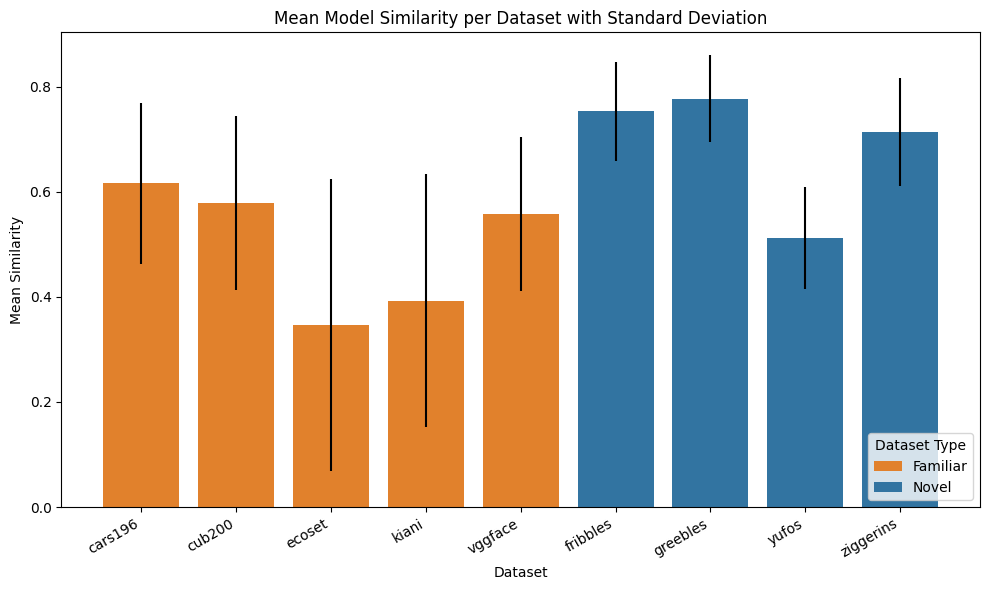


Sims Dataset Summary:
  Dataset  Mean Similarity  SD Similarity       Min      Max    Range     Type  Images per Category
  cars196         0.615799       0.153795 -0.129094 1.000000 1.129094 Familiar                    1
   cub200         0.578924       0.165079 -0.329581 1.000000 1.329581 Familiar                    1
   ecoset         0.347262       0.277776 -0.440663 1.000001 1.440663 Familiar                    1
    kiani         0.392835       0.240470 -0.533821 1.000000 1.533821 Familiar                   15
  vggface         0.557691       0.146407 -0.114364 1.000000 1.114365 Familiar                    1
 fribbles         0.753368       0.094057 -0.128753 1.000000 1.128753    Novel                    9
 greebles         0.777095       0.083123  0.016161 1.000000 0.983839    Novel                   16
    yufos         0.511488       0.097112 -0.044860 1.000000 1.044860    Novel                   12
ziggerins         0.713260       0.102614 -0.052101 1.000000 1.052101    Nove

In [44]:
from scipy.stats import ttest_ind, pearsonr
# read in sims data for nine datasets
sims_data_folder = "data/sims/"

# read all files in the folder
sims_data_files = [f for f in os.listdir(sims_data_folder) if f.endswith('.csv')]
familiar_datasets = ["cars196", "cub200", "ecoset", "kiani", "vggface"]
novel_datasets = ["fribbles", "greebles", "yufos", "ziggerins"]
dataset_order = familiar_datasets + novel_datasets

sims_dict = {}
for f in sims_data_files:
    dataset_name = f.replace('.csv', '').lower()
    df = pd.read_csv(os.path.join(sims_data_folder, f), index_col=0)
    mat = df.values.astype(float)
    sims_dict[dataset_name] = mat


# summarize each sims matrix with basic data
summary = []
for name, mat in sims_dict.items():
    upper_tri = mat[np.triu_indices_from(mat, k=1)]
    summary.append({
        "Dataset": name,
        "Mean Similarity": np.mean(upper_tri),
        "SD Similarity": np.std(upper_tri),
        "Min": np.min(upper_tri),
        "Max": np.max(upper_tri),
        "Range": np.max(upper_tri) - np.min(upper_tri)
    })

summary_df = pd.DataFrame(summary)


# Add dataset type and images per category 
summary_df["Type"] = summary_df["Dataset"].apply(lambda x: "Familiar" if x in ["ecoset", "cub200", "cars196", "vggface", "kiani"] else "Novel")
summary_df["Images per Category"] = summary_df["Dataset"].map({
    "ecoset": 1, "cub200": 1, "cars196": 1, "vggface": 1, "kiani": 15,
    "greebles": 16, "ziggerins": 12, "yufos": 12, "fribbles": 9
})

# Sort and enforce dataset order for summary_df
summary_df["Dataset"] = pd.Categorical(summary_df["Dataset"], categories=dataset_order, ordered=True)
summary_df = summary_df.sort_values("Dataset")

# Statistical summaries
# Familiar vs. Novel mean similarity
fam = summary_df[summary_df["Type"] == "Familiar"]
nov = summary_df[summary_df["Type"] == "Novel"]
t_stat, p_val = ttest_ind(fam["Mean Similarity"], nov["Mean Similarity"])
print(f"Familiar vs. Novel Mean Similarity: t = {t_stat:.2f}, p = {p_val:.3f}")

# Correlation between images per category and mean similarity
r, p = pearsonr(summary_df["Images per Category"], summary_df["Mean Similarity"])
print(f"Images per Category vs. Mean Similarity: r = {r:.2f}, p = {p:.3f}")


# Plotting
# Plot violin plot of similarity distributions
sims_flattened = []
for name, mat in sims_dict.items():
    values = mat[np.triu_indices_from(mat, k=1)]
    sims_flattened += [(name, val) for val in values]

df_plot = pd.DataFrame(sims_flattened, columns=["Dataset", "Similarity"])
df_plot["Dataset"] = pd.Categorical(df_plot["Dataset"], categories=dataset_order, ordered=True)
# Add Type info to df_plot to match summary_df
type_map = dict(zip(summary_df["Dataset"], summary_df["Type"]))
df_plot["Type"] = df_plot["Dataset"].map(type_map)

# Define consistent color palette for Familiar (orange) and Novel (blue)
custom_palette = {"Familiar": "#ff7f0e", "Novel": "#1f77b4"}  # orange, blue

plt.figure(figsize=(10, 6))
sns.violinplot(x="Dataset", y="Similarity", data=df_plot, hue="Type", palette=custom_palette, split=True, inner="box")
plt.xticks(rotation=30, ha='right')
plt.title("Distribution of Model Similarities Across Datasets")
plt.legend(title="Dataset Type", loc="lower right")
plt.tight_layout()
plt.savefig(f"{folder_save_plot}/test_dataset_violin_sims_by_dataset.png")
plt.show()

# Barplot of mean similarity with SD
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, x="Dataset", y="Mean Similarity", hue="Type", palette=custom_palette)
plt.errorbar(x=np.arange(len(summary_df)), y=summary_df["Mean Similarity"], 
             yerr=summary_df["SD Similarity"], fmt='none', c='black')
plt.title("Mean Model Similarity per Dataset with Standard Deviation")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Dataset Type", loc="lower right")
plt.tight_layout()
plt.savefig(f"{folder_save_plot}/test_dataset_barplot_mean_similarity.png")
plt.show()

# Print Summary Table
print("\nSims Dataset Summary:")
print(summary_df.to_string(index=False))

# save summary table
summary_df.to_csv(f"{folder_save}/test_dataset_stat_summary.csv", index=False)